# Multi-Space Clustering Defense for Federated Learning

## Datasets & Architecture
| Dataset | Model | Rounds |
|---|---|---|
| MNIST | SimpleCNN | 30 |
| CIFAR-10 | ResNet-18 Light (~2.7M params) | 50 |
| UNSW-NB15 | MLP (tabular) | 80 |

### Baselines
| Method | Paper |
|---|---|
| Krum | Blanchard et al., NeurIPS 2017 |
| FoolsGold | Fung et al., RAID 2020 |
| FLAME | Nguyen et al., USENIX Security 2022 |

### Experiment Modes
| Mode | Swept Parameter | Datasets |
|---|---|---|
| `alpha_sweep` | Dirichlet α ∈ {0.05, 0.1, 0.3, 0.5, 1.0} | All three |
| `pmr_sweep` | Attacker fraction ∈ {0.1, 0.2, 0.3, 0.4} | All three |
| `client_sweep` | N clients ∈ {10, 20, 50, 100} | All three |
| `stealth_sweep` | Activation prob ∈ {0.3, 0.5, 0.7, 0.85, 1.0} | All three |
| `poison_sweep` | Poison rate ∈ {0.1, 0.2, 0.3, 0.4} | All three |

## Setup & Imports

In [43]:
# =========================
# Imports + Utilities
# =========================
import os, math, copy, random, re, pickle, time, traceback, hashlib
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from collections import deque, defaultdict, Counter
from itertools import product
from datetime import datetime
import hdbscan as hdbscan_lib
from sklearn.metrics.pairwise import cosine_similarity as _cos_sim
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.utils import resample
import matplotlib.pyplot as plt
import psutil   # RAM monitoring
import os
os.chdir(os.path.expanduser("~"))
print(f"Working directory set to: {os.getcwd()}")
EPS = 1e-8

# -------------------------
# Device & Reproducibility
# -------------------------
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int, deterministic: bool = True):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
DEVICE = get_device()
print(f"Device  : {DEVICE} | Seed: {SEED}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"RAM     : {psutil.virtual_memory().total/1e9:.1f} GB")

# -------------------------
# Distance Utils
# -------------------------
def cosine_dist(a, b):
    denom = max(np.linalg.norm(a) * np.linalg.norm(b), EPS)
    return 1.0 - np.dot(a, b) / denom

def l2_dist(a, b):
    return np.linalg.norm(a - b)

def batch_cosine_similarity(vectors):
    norms = np.linalg.norm(vectors, axis=1, keepdims=True) + EPS
    normalized = vectors / norms
    return normalized @ normalized.T

# -------------------------
# Checkpoint Path
# -------------------------
def make_checkpoint_path(params: dict, base_dir: str = "results/checkpoints") -> str:
    short      = f"{params['dataset']}_a{params['dirichlet_alpha']}_s{params['seed']}"
    param_str  = "_".join(f"{k}-{v}" for k, v in sorted(params.items()))
    param_hash = hashlib.md5(param_str.encode()).hexdigest()[:10]
    filename   = f"{short}_{param_hash}.pkl"
    return os.path.join(base_dir, filename)

# -------------------------
# Resource Monitor
# -------------------------
class ResourceMonitor:
    """
    Tracks computational, memory, communication and storage overhead
    per method per round — used for paper overhead analysis table.

    Reported metrics:
      - Avg round time (s)     : total time per method per round
      - Peak VRAM (MB)         : max GPU memory allocated per round
      - Detection time (ms)    : aggregation/detection overhead only
      - Communication (MB)     : bytes transmitted per round
      - Extra storage (MB)     : method-specific persistent storage
    """
    def __init__(self, model_param_count: int, bytes_per_param: int = 4):
        self.model_param_count     = model_param_count
        self.bytes_per_param       = bytes_per_param
        # Communication cost per client per round — params only (float32)
        self.comm_bytes_per_client = model_param_count * bytes_per_param

        # Per-method accumulators
        self.round_times:  Dict[str, list] = {}
        self.peak_vram_mb: Dict[str, list] = {}
        self.detect_ms:    Dict[str, list] = {}
        self._round_start: float = 0.0

    def start_round(self, method: str):
        """Call at start of each method's round."""
        if method not in self.round_times:
            self.round_times[method]  = []
            self.peak_vram_mb[method] = []
            self.detect_ms[method]    = []
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
        self._round_start = time.time()

    def end_round(self, method: str):
        """Call at end of each method's round."""
        elapsed = time.time() - self._round_start
        self.round_times[method].append(elapsed)
        if torch.cuda.is_available():
            peak = torch.cuda.max_memory_allocated() / 1e6   # MB
        else:
            peak = 0.0
        self.peak_vram_mb[method].append(peak)

    def log_detect_time(self, method: str, ms: float):
        """Log detection/aggregation overhead in milliseconds."""
        if method in self.detect_ms:
            self.detect_ms[method].append(ms)

    def comm_mb_per_round(self, n_participants: int) -> float:
        """Total upload communication cost per round in MB."""
        return (self.comm_bytes_per_client * n_participants) / 1e6

    def storage_bytes(
        self,
        method:            str,
        foolsgold_history: Dict = None,
        client_states:     List = None,
    ) -> Dict:
        """
        Estimate per-method extra storage overhead beyond the global model.

        - Krum  : none
        - FLAME : none
        - FoolsGold : cumulative gradient history per participating client
                      size = n_clients × d × 4 bytes
                      e.g. CIFAR-10: 20 × 2.7M × 4 = 216 MB
        - Ours  : Z_final + last_weight + bounded history deques per client
                  size ≈ negligible (< 1 KB total for 20 clients)
        """
        out = {"method": method, "extra_storage_mb": 0.0, "description": "none"}

        if method == "foolsgold" and foolsgold_history is not None:
            total_bytes = sum(v.nbytes for v in foolsgold_history.values())
            out["extra_storage_mb"] = total_bytes / 1e6
            out["description"]      = (f"cumulative gradient history: "
                                        f"{len(foolsgold_history)} clients")

        elif method == "Ours" and client_states is not None:
            n              = len(client_states)
            history_window = client_states[0].history_window if client_states else 20
            # Z_final (8B) + last_weight (8B) + 3 spaces × 2 deques × window × 8B
            extra = n * (2 * 8 + 3 * 2 * history_window * 8)
            out["extra_storage_mb"] = extra / 1e6
            out["description"]      = f"Z_final + history deques: {n} clients"

        return out

    def summary(
        self,
        n_participants:    int,
        foolsgold_history: Dict = None,
        client_states:     List = None,
    ) -> pd.DataFrame:
        """Return overhead DataFrame for paper table."""
        rows = []
        for method in self.round_times:
            avg_time = np.mean(self.round_times[method])
            avg_vram = np.mean(self.peak_vram_mb[method])
            avg_det  = np.mean(self.detect_ms[method]) if self.detect_ms[method] else 0.0
            comm_mb  = self.comm_mb_per_round(n_participants)
            storage  = self.storage_bytes(method, foolsgold_history, client_states)
            rows.append({
                "Method":           method,
                "Avg Round (s)":    round(avg_time, 2),
                "Peak VRAM (MB)":   round(avg_vram, 1),
                "Detection (ms)":   round(avg_det, 1),
                "Comm MB/round":    round(comm_mb, 1),
                "Extra Storage MB": round(storage["extra_storage_mb"], 3),
                "Storage Info":     storage["description"],
            })
        return pd.DataFrame(rows)

print("Imports ready.")
print("ResourceMonitor defined.")

Working directory set to: C:\Users\sesalf
Device  : cuda | Seed: 42
GPU     : NVIDIA GeForce RTX 5080
VRAM    : 17.1 GB
RAM     : 68.1 GB
Imports ready.
ResourceMonitor defined.


In [44]:
# ==========================================================
# RESET CHECKPOINTS.
# Comment out after running once.
# # ==========================================================

import shutil

shutil.rmtree("results/checkpoints", ignore_errors=True)
os.makedirs("results/checkpoints",          exist_ok=True)
os.makedirs("results/checkpoints/progress", exist_ok=True)

print("Checkpoints cleared. Ready to run fresh experiments.")

Checkpoints cleared. Ready to run fresh experiments.


In [45]:
# =========================
# Experiment Configuration
# =========================

DATASET = "mnist"   # "mnist" | "cifar10" | "unsw"
EXPERIMENT_NAME = "strong_attack"

DATASET_CONFIG = {
    "mnist":         {"num_classes": 10,  "input_channels": 1, "img_size": 28, "name": "MNIST"},
    "cifar10":       {"num_classes": 10,  "input_channels": 3, "img_size": 32, "name": "CIFAR-10"},
    "unsw":          {"num_classes": 10,  "input_dim": 42,     "name": "UNSW-NB15"},  # tabular
}

assert DATASET in DATASET_CONFIG, f"DATASET must be one of {list(DATASET_CONFIG.keys())}"
config      = DATASET_CONFIG[DATASET]
num_classes = config["num_classes"]
is_tabular  = "input_dim" in config

input_channels = config.get("input_channels")
img_size       = config.get("img_size")
input_dim      = config.get("input_dim")

DEFAULT_ROUNDS = {
    "mnist":         30,
    "cifar10":       60,
    "unsw":          80,
    "default":       50,
}
LOCAL_LR = {
    "mnist":         0.01,
    "cifar10":       0.01,
    "unsw":          0.01,
    "default":       0.01,
}
MAD_MULTIPLIER = {
    "mnist":         1.5,
    "cifar10":       2.0,
    "unsw":          1.5,
    "default":       2.0,
}
GATE_THRESHOLD = {
    "mnist":         0.60,
    "cifar10":       0.65,
    "unsw":          0.60,
    "default":       0.65,
}
COLD_START_ROUNDS = {
    "mnist":         5,
    "cifar10":       10,
    "unsw":          5,
    "default":       5,
}
SOFT_KEEP = {
    "mnist":         0.10,
    "cifar10":       0.30,
    "unsw":          0.10,
    "default":       0.20,
}
WEIGHT_DECAY  = {
    "mnist":         0.0,
    "cifar10":       0.0001,
    "unsw":          0.0,
    "default":       0.0,
}
MIN_WEIGHT   = {
    "mnist":         0.01,
    "cifar10":       0.05,
    "unsw":          0.01,
    "default":       0.01,
}
DIRICHLET_ALPHAS = [0.05, 0.1, 0.3, 0.5, 1.0]
DEFAULT_ALPHA    = 0.3

EXP_CONFIG = {
    # FL setup
    "rounds":          DEFAULT_ROUNDS.get(DATASET, DEFAULT_ROUNDS["default"]),
    "n_clients":       20,
    "client_frac":     0.50,
    "dirichlet_alpha": DEFAULT_ALPHA,

    # Attack
    "attacker_frac":             0.20,
    "poison_rate":               0.25,
    "target_label":              0,
    "stealth_activation_period": 2,
    "stealth_activation_prob":   0.85,

    # Local training
    "local_epochs": 5,
    "local_lr":     LOCAL_LR.get(DATASET, LOCAL_LR["default"]),
    "weight_decay": WEIGHT_DECAY.get(DATASET, WEIGHT_DECAY["default"]),   # ← Stage 1 winner


    # Aggregation
    "min_weight":   MIN_WEIGHT.get(DATASET, MIN_WEIGHT["default"]),

    # Defense
    "detection_strategy":   "multi_gate",
    "history_len":       20,
    "use_cold_start":       True,
    "cold_start_rounds":    COLD_START_ROUNDS.get(DATASET, COLD_START_ROUNDS["default"]),
    "soft_keep":            SOFT_KEEP.get(DATASET, SOFT_KEEP["default"]),
    "normalization_method": "mad",
    "mad_multiplier":       MAD_MULTIPLIER.get(DATASET, MAD_MULTIPLIER["default"]),
    "max_flag_fraction":    0.20,
    "gate_threshold":       GATE_THRESHOLD.get(DATASET, GATE_THRESHOLD["default"]),


    "decay":    0.99,
    "lambda_w": 3.0,
    # Logging
    "show_round_details":   False,
}

# -------------------------
# Sanity checks
# -------------------------
assert 0 < EXP_CONFIG["client_frac"] <= 1
assert 0 <= EXP_CONFIG["attacker_frac"] < 1
assert 0 <= EXP_CONFIG["poison_rate"] <= 1
assert 0 <= EXP_CONFIG["target_label"] < num_classes
assert EXP_CONFIG["rounds"] >= 1
assert EXP_CONFIG["n_clients"] >= 2
assert EXP_CONFIG["dirichlet_alpha"] > 0
assert all(a > 0 for a in DIRICHLET_ALPHAS)
assert EXP_CONFIG["cold_start_rounds"] < EXP_CONFIG["rounds"]
assert EXP_CONFIG["normalization_method"] in ["minmax", "mad", "none"]

if EXP_CONFIG["detection_strategy"] == "multi_gate":
    assert 0.0 <= EXP_CONFIG["gate_threshold"] <= 1.0
    assert EXP_CONFIG["mad_multiplier"] > 0.0
    assert 0.0 < EXP_CONFIG["max_flag_fraction"] <= 1.0

# -------------------------
# Print summary
# -------------------------
print("=" * 70)
print(f" EXPERIMENT: {config['name']} - {EXPERIMENT_NAME}")
print("=" * 70)
if is_tabular:
    print(f"Dataset  : {config['name']} | Classes={num_classes} | InputDim={input_dim} (tabular)")
else:
    print(f"Dataset  : {config['name']} | Classes={num_classes} | Channels={input_channels} | Size={img_size}x{img_size}")
print(f"Device   : {DEVICE} | Seed: {SEED}")
print(f"Rounds={EXP_CONFIG['rounds']} | Clients={EXP_CONFIG['n_clients']} | ClientFrac={EXP_CONFIG['client_frac']}")
print(f"Dirichlet alpha sweep : {DIRICHLET_ALPHAS}  (default={DEFAULT_ALPHA})")
print(f"Attack   : attackers={EXP_CONFIG['attacker_frac']*100:.0f}% | poison={EXP_CONFIG['poison_rate']*100:.0f}% | target={EXP_CONFIG['target_label']}")
print(f"Stealth  : period={EXP_CONFIG['stealth_activation_period']} | prob={EXP_CONFIG['stealth_activation_prob']}")
print(f"Local    : epochs={EXP_CONFIG['local_epochs']} | lr={EXP_CONFIG['local_lr']}")
print()
print(" DEFENSE: Pure CV Temporal Detector (TASAD)")
print(f"  Signal       : CV of late layer norm history")
print(f"  Strategy     : {EXP_CONFIG['detection_strategy']}")
print(f"  Normalization: {EXP_CONFIG['normalization_method']}")
print(f"  Cold start   : {'Enabled' if EXP_CONFIG['use_cold_start'] else 'Disabled'} ({EXP_CONFIG['cold_start_rounds']} rounds)")
print(f"  Decay        : {EXP_CONFIG['decay']}")
print(f"  Weight       : exp(-{EXP_CONFIG['lambda_w']}*Z) with floor={EXP_CONFIG['min_weight']}")
print(f"  Detection    : gate={EXP_CONFIG['gate_threshold']} | MAD x{EXP_CONFIG['mad_multiplier']} | max_flag={EXP_CONFIG['max_flag_fraction']*100:.0f}%")
print("=" * 70)

 EXPERIMENT: MNIST - strong_attack
Dataset  : MNIST | Classes=10 | Channels=1 | Size=28x28
Device   : cuda | Seed: 42
Rounds=30 | Clients=20 | ClientFrac=0.5
Dirichlet alpha sweep : [0.05, 0.1, 0.3, 0.5, 1.0]  (default=0.3)
Attack   : attackers=20% | poison=25% | target=0
Stealth  : period=2 | prob=0.85
Local    : epochs=5 | lr=0.01

 DEFENSE: Pure CV Temporal Detector (TASAD)
  Signal       : CV of late layer norm history
  Strategy     : multi_gate
  Normalization: mad
  Cold start   : Enabled (5 rounds)
  Decay        : 0.99
  Weight       : exp(-3.0*Z) with floor=0.01
  Detection    : gate=0.6 | MAD x1.5 | max_flag=20%


## MODEL DEFINITIONS + VECTOR UTILITIES


In [46]:
# ============================================
# MODEL DEFINITIONS + VECTOR UTILITIES
# ============================================

# ── MNIST: Simple CNN ────────────────────────────────────
class SimpleCNN(nn.Module):
    """Lightweight CNN for MNIST (1ch, 28x28, 10 classes)."""
    def __init__(self, num_classes=10, input_channels=1, img_size=28):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)

        with torch.no_grad():
            d = torch.zeros(1, input_channels, img_size, img_size)
            d = self.pool(F.relu(self.conv1(d)))
            d = self.pool(F.relu(self.conv2(d)))
            fc_in = d.flatten(1).shape[1]

        self.fc1 = nn.Linear(fc_in, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


# ── CIFAR-10: ResNet-18 ──────────────────────────────────
class BasicBlock(nn.Module):
    """Standard ResNet-18 residual block."""
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class ResNet18(nn.Module):
    """
    ResNet-18 adapted for small images (CIFAR-10 32x32).
    First conv 3x3 stride=1, no maxpool.
    Matches FLAME's ResNet-18 Light setup for CIFAR-10.
    """
    def __init__(self, num_classes=10, input_channels=3, img_size=32):
        super().__init__()

        # Adaptive first layer — no aggressive downsampling for small images
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)

        # Residual layers
        self.layer1 = self._make_layer(64,  64,  2, stride=1)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc  = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = [BasicBlock(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x)
        x = x.flatten(1)
        return self.fc(x)


# ── UNSW-NB15: MLP
class UNSWMLP(nn.Module):
    """4-layer MLP for UNSW-NB15 tabular intrusion-detection data."""
    def __init__(self, input_dim=42, num_classes=10):
        super().__init__()
        self.fc1     = nn.Linear(input_dim, 128)
        self.fc2     = nn.Linear(128, 64)
        self.fc3     = nn.Linear(64, 32)
        self.fc4     = nn.Linear(32, num_classes)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.dropout(self.relu(self.fc3(x)))
        return self.fc4(x)


# ── Model factory ────────────────────────────────────────
def build_model(dataset_name: str, num_classes: int,
                input_channels: int = None, img_size: int = None,
                input_dim: int = None) -> nn.Module:
    """Return the correct model for a given dataset."""
    if dataset_name == "mnist":
        return SimpleCNN(num_classes, input_channels, img_size)
    elif dataset_name == "cifar10":
        return ResNet18(num_classes, input_channels, img_size)
    elif dataset_name == "unsw":
        return UNSWMLP(input_dim=input_dim, num_classes=num_classes)
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")


# ============================================
# VECTOR UTILITIES
# ============================================

def _float_buffers_in_order(model: nn.Module):
    """Float buffers only — excludes integer buffers like num_batches_tracked."""
    return [(n, b) for n, b in model.named_buffers()
            if b is not None and torch.is_floating_point(b)]

@torch.no_grad()
def get_model_params_vector(model: nn.Module) -> np.ndarray:
    """Flatten parameters only — used for computing client update deltas."""
    return torch.cat([p.detach().view(-1).cpu()
                      for p in model.parameters()]).numpy().astype(np.float32)

@torch.no_grad()
def get_model_state_vector(model: nn.Module) -> np.ndarray:
    """Flatten parameters + float buffers — used for FL aggregation."""
    params = [p.detach().view(-1).cpu() for p in model.parameters()]
    bufs   = [b.detach().view(-1).cpu() for _, b in _float_buffers_in_order(model)]
    return torch.cat(params + bufs).numpy().astype(np.float32)

@torch.no_grad()
def set_model_state_vector(model: nn.Module, vec: np.ndarray) -> None:
    """Restore parameters + float buffers from vector."""
    vec    = np.asarray(vec, dtype=np.float32)
    offset = 0
    for p in model.parameters():
        n = p.numel()
        p.copy_(torch.from_numpy(vec[offset:offset+n]).view_as(p).to(p.device, p.dtype))
        offset += n
    for _, b in _float_buffers_in_order(model):
        n = b.numel()
        b.copy_(torch.from_numpy(vec[offset:offset+n]).view_as(b).to(b.device, b.dtype))
        offset += n


# ============================================
# INSTANTIATE GLOBAL MODEL
# ============================================

model = build_model(DATASET, num_classes, input_channels, img_size, input_dim).to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
num_float_bufs  = len(_float_buffers_in_order(model))
arch_name       = model.__class__.__name__

# Model size in MB — float32 = 4 bytes per parameter
model_size_mb   = total_params * 4 / 1e6

# Communication cost per client per round, each client uploads full model
# In FL, communication cost = model size × n_participants per round
n_participants  = max(1, int(EXP_CONFIG["client_frac"] * EXP_CONFIG["n_clients"]))
comm_per_round  = model_size_mb * n_participants

print(f" Model      : {arch_name}")
if is_tabular:
    print(f" Dataset    : {DATASET} | InputDim={input_dim} | {num_classes} classes")
else:
    print(f" Dataset    : {DATASET} | {input_channels}ch | {img_size}×{img_size} | {num_classes} classes")
print(f" Parameters : {total_params:,}")
print(f" Model size : {model_size_mb:.1f} MB  (float32)")
print(f" Float bufs : {num_float_bufs}  (int buffers excluded from aggregation)")
print(f" Comm cost  : {model_size_mb:.1f} MB/client × {n_participants} clients"
      f" = {comm_per_round:.1f} MB/round  ← for paper overhead table")

 Model      : SimpleCNN
 Dataset    : mnist | 1ch | 28×28 | 10 classes
 Parameters : 421,642
 Model size : 1.7 MB  (float32)
 Float bufs : 0  (int buffers excluded from aggregation)
 Comm cost  : 1.7 MB/client × 10 clients = 16.9 MB/round  ← for paper overhead table


## Backdoor Attack Definition

In [47]:
# ============================================
# BACKDOOR ATTACK (NORMALIZATION-AWARE)
# ============================================

# Normalization statistics per dataset (image only)
DATASET_STATS = {
    "mnist":   (None, None),
    "cifar10": ([0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010]),
}

# Trigger size per dataset (image only)
TRIGGER_SIZE = {
    "mnist":   2,
    "cifar10": 4,
}

# Tabular trigger settings (UNSW-NB15)
# Additive perturbation on selected low-variance continuous features
# in post-StandardScaler space
TABULAR_TRIGGER_STRENGTH   = {"unsw": 1.0}
TABULAR_TRIGGER_N_FEATURES = {"unsw": 4}
TABULAR_TRIGGER_JITTER_STD = {"unsw": 0.1}


class TriggerConfig:
    """Global trigger configuration — set once per dataset."""
    mode:       str          = None   # "image" | "tabular"
    value:      torch.Tensor = None
    size:       int          = 2      # image only
    features:   list         = None   # tabular only
    jitter_std: float        = 0.0    # tabular only
    dataset:    str          = None

    @classmethod
    def reset(cls):
        cls.mode       = None
        cls.value      = None
        cls.size       = 2
        cls.features   = None
        cls.jitter_std = 0.0
        cls.dataset    = None


def set_trigger_value(
    dataset_name:    str,
    X_train:         np.ndarray = None,
    raw_variances:   np.ndarray = None,
    continuous_mask: np.ndarray = None,
    feature_names:   list       = None,
) -> None:
    """
    Set trigger value/size/features based on dataset.
    Image datasets: white square patch, bottom-right corner.
    Tabular datasets: additive perturbation on k low-variance features.
    """
    if dataset_name in DATASET_STATS:
        # ── Image trigger ────────────────────────────────
        mean, std = DATASET_STATS[dataset_name]
        TriggerConfig.mode = "image"

        if mean is None:
            TriggerConfig.value = torch.tensor(1.0)
        else:
            mean_t = torch.tensor(mean).view(-1, 1, 1)
            std_t  = torch.tensor(std).view(-1, 1, 1)
            TriggerConfig.value = (1.0 - mean_t) / std_t

        TriggerConfig.size    = TRIGGER_SIZE[dataset_name]
        TriggerConfig.dataset = dataset_name

        val = TriggerConfig.value
        val_str = f"{val.item():.3f}" if val.dim() == 0 else \
                  f"[{val.min().item():.2f}, {val.max().item():.2f}]"
        print(f"Trigger set for {dataset_name}: "
              f"size={TriggerConfig.size}x{TriggerConfig.size} | "
              f"position=bottom-right | "
              f"value range={val_str}  (normalized pixel space)")

    elif dataset_name in TABULAR_TRIGGER_STRENGTH:
        # ── Tabular trigger ──────────────────────────────
        assert raw_variances is not None, \
            f"{dataset_name} trigger requires raw_variances"

        TriggerConfig.mode = "tabular"
        k = TABULAR_TRIGGER_N_FEATURES[dataset_name]

        # Select k lowest-variance continuous features
        if continuous_mask is not None:
            eligible_idx = np.where(continuous_mask)[0]
            order = np.argsort(raw_variances[eligible_idx])[:k]
            TriggerConfig.features = eligible_idx[order].tolist()
        else:
            TriggerConfig.features = np.argsort(raw_variances)[:k].tolist()

        TriggerConfig.value      = torch.tensor(TABULAR_TRIGGER_STRENGTH[dataset_name])
        TriggerConfig.jitter_std = TABULAR_TRIGGER_JITTER_STD.get(dataset_name, 0.0)
        TriggerConfig.dataset    = dataset_name

        feat_labels = (
            [feature_names[i] for i in TriggerConfig.features]
            if feature_names else TriggerConfig.features
        )
        print(f"Trigger set for {dataset_name}: "
              f"features={feat_labels} (idx={TriggerConfig.features}) | "
              f"mean perturbation={TriggerConfig.value.item():.2f} "
              f"± {TriggerConfig.jitter_std:.2f} jitter  (post-scaling tabular space)")

        if X_train is not None:
            for f in TriggerConfig.features:
                col  = X_train[:, f]
                name = feature_names[f] if feature_names else f"feature_{f}"
                print(f"    [{name}] post-scaling train range: "
                      f"min={col.min():.2f} max={col.max():.2f}")

    else:
        raise ValueError(
            f"Unknown dataset: '{dataset_name}'. "
            f"Available: {list(DATASET_STATS.keys()) + list(TABULAR_TRIGGER_STRENGTH.keys())}"
        )


def add_trigger(x: torch.Tensor) -> torch.Tensor:
    """
    Add trigger to a sample or batch.
    Image mode:   square patch in bottom-right corner.
    Tabular mode: additive perturbation on selected feature columns.
    """
    assert TriggerConfig.mode is not None, \
        "Call set_trigger_value(dataset_name, ...) before add_trigger()"

    x = x.clone()

    if TriggerConfig.mode == "image":
        s   = TriggerConfig.size
        val = TriggerConfig.value.to(x.device)
        if x.dim() == 3:
            H, W = x.shape[1], x.shape[2]
            x[:, H-s:H, W-s:W] = val
        elif x.dim() == 4:
            H, W = x.shape[2], x.shape[3]
            x[:, :, H-s:H, W-s:W] = val
        else:
            raise ValueError(f"Expected 3D or 4D image tensor, got {x.dim()}D")

    elif TriggerConfig.mode == "tabular":
        feats = TriggerConfig.features
        val   = TriggerConfig.value.to(x.device)
        jstd  = TriggerConfig.jitter_std
        if x.dim() == 1:
            jitter = torch.randn(len(feats), device=x.device) * jstd if jstd > 0 else 0.0
            x[feats] = x[feats] + val + jitter
        elif x.dim() == 2:
            jitter = torch.randn(x.shape[0], len(feats), device=x.device) * jstd if jstd > 0 else 0.0
            x[:, feats] = x[:, feats] + val + jitter
        else:
            raise ValueError(f"Expected 1D or 2D tabular tensor, got {x.dim()}D")

    return x


class BackdoorWrapper(Dataset):
    """Dataset wrapper that poisons a fixed fraction of samples."""
    def __init__(self, base: Dataset, target_label: int,
                 poison_rate: float, seed: int = 0):
        self.base         = base
        self.target_label = target_label

        n   = len(base)
        rng = np.random.RandomState(seed)
        k   = int(round(poison_rate * n))
        self.poison_idx = set(rng.choice(n, size=k, replace=False).tolist())

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if idx in self.poison_idx:
            x = add_trigger(x)
            y = torch.tensor(self.target_label, dtype=y.dtype) \
                if torch.is_tensor(y) else self.target_label
        return x, y


def make_triggered_loader(dataset: Dataset,
                          batch_size: int = 256) -> DataLoader:
    """Create loader with ALL samples triggered — used for ASR evaluation."""
    class AlwaysTriggered(Dataset):
        def __init__(self, base):
            self.base = base
        def __len__(self):
            return len(self.base)
        def __getitem__(self, idx):
            x, y = self.base[idx]
            return add_trigger(x), y

    return DataLoader(AlwaysTriggered(dataset),
                      batch_size=batch_size, shuffle=False)


# Initialize trigger for current dataset

if DATASET in DATASET_STATS:
    set_trigger_value(DATASET)
else:
    print(f"  Trigger init for '{DATASET}' deferred to "
          f"build_federated_dataset() (requires raw feature stats).")

Trigger set for mnist: size=2x2 | position=bottom-right | value range=1.000  (normalized pixel space)


## Data Preparation

In [48]:
# ============================================
# UNSW-NB15 LOADER
# ============================================

UNSW_TRAIN_CSV = "data/UNSW_NB15_training-set.csv"
UNSW_TEST_CSV  = "data/UNSW_NB15_testing-set.csv"

UNSW_TARGET_COL  = "attack_cat"
UNSW_LEAK_COLS   = ["label"]
UNSW_META_COLS   = ["id"]
UNSW_CONTINUOUS_MIN_UNIQUE = 20


class UNSWDataset(Dataset):
    """Wraps preprocessed UNSW-NB15 arrays as a torch Dataset."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def load_unsw_raw(
    train_csv: str = UNSW_TRAIN_CSV,
    test_csv:  str = UNSW_TEST_CSV,
    seed:      int = 0,
    max_class_ratio: float = 10.0,
):
    """
    Load and preprocess UNSW-NB15 using official pre-split CSVs.
    Multiclass target (attack_cat, 10 classes).
    """
    if not (os.path.exists(train_csv) and os.path.exists(test_csv)):
        raise FileNotFoundError(
            f"UNSW-NB15 CSVs not found at '{train_csv}' / '{test_csv}'. "
            f"Download UNSW_NB15_training-set.csv and UNSW_NB15_testing-set.csv "
            f"(e.g. Kaggle: mrwellsdavid/unsw-nb15) into ./data/, or set "
            f"UNSW_TRAIN_CSV / UNSW_TEST_CSV above to their location."
        )
    train_df = pd.read_csv(train_csv)
    test_df  = pd.read_csv(test_csv)

    train_df["_split"] = "train"
    test_df["_split"]  = "test"
    df = pd.concat([train_df, test_df], ignore_index=True)

    drop_cols = [c for c in UNSW_META_COLS + UNSW_LEAK_COLS if c in df.columns]
    df = df.drop(columns=drop_cols)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
    df = df.dropna()

    cat_cols = [c for c in df.select_dtypes(include=["object"]).columns
                if c not in (UNSW_TARGET_COL, "_split")]
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    target_encoder = LabelEncoder()
    df[UNSW_TARGET_COL] = target_encoder.fit_transform(df[UNSW_TARGET_COL].astype(str))
    class_names = target_encoder.classes_.tolist()
    print(f" UNSW-NB15 attack_cat encoding: "
          + ", ".join(f"{i}={n}" for i, n in enumerate(class_names)))

    counts        = df[UNSW_TARGET_COL].value_counts()
    minority_size = int(counts.min())
    cap           = int(minority_size * max_class_ratio)

    capped = []
    for cls_idx in counts.index:
        cls_df = df[df[UNSW_TARGET_COL] == cls_idx]
        if len(cls_df) > cap:
            cls_df = resample(cls_df, n_samples=cap, random_state=seed, replace=False)
        capped.append(cls_df)

    balanced = pd.concat(capped).sample(frac=1, random_state=seed).reset_index(drop=True)
    print(f" UNSW-NB15 class balance after cap: "
          f"{dict(balanced[UNSW_TARGET_COL].value_counts().sort_index())}")

    split_marker  = balanced["_split"]
    feature_names = balanced.drop(columns=[UNSW_TARGET_COL, "_split"]).columns.tolist()
    X = balanced.drop(columns=[UNSW_TARGET_COL, "_split"]).values.astype(np.float32)
    y = balanced[UNSW_TARGET_COL].values.astype(np.int64)

    raw_variances   = X.var(axis=0)
    cat_col_set     = set(cat_cols)
    continuous_mask = np.array([
        (name not in cat_col_set) and
        (len(np.unique(X[:, i])) >= UNSW_CONTINUOUS_MIN_UNIQUE)
        for i, name in enumerate(feature_names)
    ])
    print(f" UNSW-NB15 feature audit: {int(continuous_mask.sum())}/{len(feature_names)} "
          f"features classified as continuous (eligible for trigger)")

    train_mask = (split_marker == "train").values
    X_train, X_test = X[train_mask], X[~train_mask]
    y_train, y_test = y[train_mask], y[~train_mask]

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f" UNSW-NB15 preprocessing done: "
          f"{X_train.shape[0]} train / {X_test.shape[0]} test | "
          f"features={X_train.shape[1]} | classes={len(class_names)}")

    return (X_train, X_test, y_train, y_test, scaler, X_train.shape[1],
            raw_variances, continuous_mask, feature_names, class_names)


# ============================================
# FEDERATED DATASET BUILDER
# ============================================

def build_federated_dataset(
    dataset_name    = "mnist",
    n_clients       = 20,
    dirichlet_alpha = 0.3,
    batch_size      = 64,
    val_size        = 500,
    seed            = 0,
    eval_batch_size = 256,
    max_retries     = 100,
):
    """
    Partition dataset with Dirichlet distribution + validation set.

    Non-IID degree controlled by dirichlet_alpha:
      - Low alpha (0.05): highly heterogeneous
      - High alpha (1.0): near-IID
    """
    rng = np.random.RandomState(seed)

    # ── Load dataset ─────────────────────────────────────
    if dataset_name == "mnist":
        set_trigger_value(dataset_name)
        tfm   = transforms.Compose([transforms.ToTensor()])
        train = datasets.MNIST("./data", train=True,  download=True, transform=tfm)
        test  = datasets.MNIST("./data", train=False, download=True, transform=tfm)
        num_classes = 10

    elif dataset_name == "cifar10":
        set_trigger_value(dataset_name)
        tfm_train = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465),
                                 (0.2023, 0.1994, 0.2010)),
        ])
        tfm_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465),
                                 (0.2023, 0.1994, 0.2010)),
        ])
        train = datasets.CIFAR10("./data", train=True,  download=True, transform=tfm_train)
        test  = datasets.CIFAR10("./data", train=False, download=True, transform=tfm_test)
        num_classes = 10

    elif dataset_name == "unsw":
        (X_train, X_test, y_train, y_test, scaler, _,
         raw_variances, continuous_mask, feature_names, class_names) = load_unsw_raw(seed=seed)
        train = UNSWDataset(X_train, y_train)
        test  = UNSWDataset(X_test,  y_test)
        num_classes = len(class_names)
        set_trigger_value(
            dataset_name,
            X_train         = X_train,
            raw_variances   = raw_variances,
            continuous_mask = continuous_mask,
            feature_names   = feature_names,
        )

    else:
        raise ValueError(
            f"Unknown dataset: '{dataset_name}'. "
            f"Choose from: mnist | cifar10 | unsw"
        )

    # ── Validation split ─────────────────────────────────
    all_idx       = np.arange(len(train))
    val_indices   = rng.choice(all_idx, size=val_size, replace=False)
    train_indices = np.setdiff1d(all_idx, val_indices)

    val_subset         = Subset(train, val_indices)
    val_loader         = DataLoader(val_subset, batch_size=eval_batch_size, shuffle=False)
    val_trigger_loader = make_triggered_loader(val_subset, batch_size=eval_batch_size)

    # ── Targets → numpy ──────────────────────────────────
    if dataset_name == "unsw":
        targets = train.y.numpy()
    elif hasattr(train, "targets"):
        targets = train.targets
        targets = targets.cpu().numpy() if torch.is_tensor(targets) else np.array(targets)
    else:
        targets = np.array([s[1] for s in train.samples])

    labels = targets[train_indices]

    # ── Dirichlet partitioning ────────────────────────────
    MIN_SAMPLES_PER_CLIENT = 30 if dataset_name == "unsw" else 1
    for attempt in range(max_retries):
        idxs_by_label  = [train_indices[labels == l] for l in range(num_classes)]
        client_indices = [[] for _ in range(n_clients)]

        for l in range(num_classes):
            idxs = idxs_by_label[l].copy()
            rng.shuffle(idxs)
            proportions = rng.dirichlet([dirichlet_alpha] * n_clients)
            splits      = (np.cumsum(proportions) * len(idxs)).astype(int)[:-1]
            parts       = np.split(idxs, splits)
            for c in range(n_clients):
                client_indices[c].extend(parts[c].tolist())

        if min(len(ci) for ci in client_indices) >= MIN_SAMPLES_PER_CLIENT:
            break
    else:
        raise RuntimeError(
            f"Could not create clients with >= {MIN_SAMPLES_PER_CLIENT} samples "
            f"after {max_retries} attempts. "
            f"Try increasing alpha ({dirichlet_alpha}) or reducing n_clients ({n_clients})."
        )

    # ── Client loaders ────────────────────────────────────
    loaders = [
        DataLoader(Subset(train, client_indices[c]),
                   batch_size=batch_size, shuffle=True)
        for c in range(n_clients)
    ]

    # ── Test loaders ──────────────────────────────────────
    test_loader         = DataLoader(test, batch_size=eval_batch_size, shuffle=False)
    trigger_test_loader = make_triggered_loader(test, batch_size=eval_batch_size)

    # ── Heterogeneity measure ─────────────────────────────
    uniform    = np.ones(num_classes) / num_classes
    emd_scores = []
    for ci in client_indices:
        if len(ci) == 0:
            continue
        client_labels = targets[ci]
        counts        = np.bincount(client_labels, minlength=num_classes)
        dist          = counts / counts.sum()
        emd_scores.append(np.sum(np.abs(dist - uniform)) / 2)
    avg_emd = float(np.mean(emd_scores))

    # ── Summary ───────────────────────────────────────────
    client_sizes = [len(ci) for ci in client_indices]
    print(f" {dataset_name.upper()} federated dataset ready:")
    print(f"   Clients      : {n_clients} | Classes: {num_classes}")
    print(f"   Validation   : {val_size} samples | Seed: {seed}")
    print(f"   Dirichlet α  : {dirichlet_alpha} (lower = more heterogeneous)")
    print(f"   Client sizes : min={min(client_sizes)} | "
          f"max={max(client_sizes)} | avg={np.mean(client_sizes):.0f}")
    print(f"   Heterogeneity: {avg_emd:.3f} avg L1 distance from uniform"
          f"  (0=IID, 1=fully non-IID)")

    return loaders, test_loader, trigger_test_loader, val_loader, val_trigger_loader

## Enhanced Client State(MultiSpaceClientState)

In [49]:
# ============================================
# CLIENT STATE
# ============================================

@dataclass
class MultiSpaceClientState:
    """
    Per-client state for multi-space temporal backdoor detection.
    Tracks clustering history across magnitude, direction, and
    representation spaces to detect stealth periodic attackers.
    No validation data required.
    """
    cid:         int
    is_attacker: bool   # ground truth — for evaluation only, never used in defense

    rounds_participated: int   = 0
    times_flagged:       int   = 0
    history_window:      int   = 20   # matches EXP_CONFIG["history_window"]

    # Aggregated suspicion score — persists across rounds
    Z_final:     float = 0.0
    last_weight: float = 1.0

    # Per-space temporal memory
    spaces: Dict[str, Dict] = field(init=False)

    def __post_init__(self):
        self.spaces = {
            "magnitude": {
                "cluster_hist":  deque(maxlen=self.history_window),
                "distance_hist": deque(maxlen=self.history_window),
                "instability":   0.0,
                "switching":     0.0,
                "Z":             0.0,
            },
            "direction": {
                "cluster_hist":  deque(maxlen=self.history_window),
                "distance_hist": deque(maxlen=self.history_window),
                "instability":   0.0,
                "switching":     0.0,
                "Z":             0.0,
            },
            "representation": {
                "cluster_hist":  deque(maxlen=self.history_window),
                "distance_hist": deque(maxlen=self.history_window),
                "instability":   0.0,
                "switching":     0.0,
                "Z":             0.0,
            },
        }

    # ── COMPATIBILITY BRIDGE PROPERTIES ──────────────────
    # These properties fix the 'no attribute distance_hist' error
    # by exposing the nested magnitude deques to the Detector.
    @property
    def distance_hist(self) -> Dict[str, deque]:
        """Provides a flat mapping of spaces to their distance histories."""
        return {name: space["distance_hist"] for name, space in self.spaces.items()}

    @property
    def cluster_hist(self) -> Dict[str, deque]:
        """Provides a flat mapping of spaces to their cluster histories."""
        return {name: space["cluster_hist"] for name, space in self.spaces.items()}

    # ── UPDATE METHODS ───────────────────────────────────
    def update_cluster(self, space: str, cluster_id: int) -> None:
        """Record cluster assignment for temporal analysis."""
        self.spaces[space]["cluster_hist"].append(cluster_id)

    def update_distance(self, space: str, dist: float) -> None:
        """Record distance to cluster centroid for instability scoring."""
        self.spaces[space]["distance_hist"].append(dist)

    def compute_switching(self, space: str) -> float:
        """
        Compute switching score with oscillation detection.
        Detects backdoor on/off pattern (e.g. 0-1-0-1-0-1).

        Returns value in [0, 1] where:
            0.0 = always in same cluster (benign)
            1.0 = maximum oscillation (suspicious)
        """
        hist = list(self.spaces[space]["cluster_hist"])
        if len(hist) < 2:
            return 0.0

        # Basic switching rate
        switches = sum(hist[i] != hist[i-1] for i in range(1, len(hist)))
        basic_switching = switches / (len(hist) - 1)

        # Oscillation detection — pattern A-B-A-B typical of periodic attacker
        if len(hist) >= 4:
            oscillations = sum(
                1 for i in range(2, len(hist))
                if hist[i] == hist[i-2] and hist[i] != hist[i-1]
            )
            oscillation_rate = oscillations / max(1, len(hist) - 2)
            return 0.5 * basic_switching + 0.5 * oscillation_rate

        return basic_switching

    def compute_instability(self, space: str) -> float:
        """
        Compute instability as coefficient of variation of centroid distances.
        Scale-invariant: works across spaces with different distance magnitudes.

        Returns value >= 0 where higher = more unstable = more suspicious.
        """
        d = list(self.spaces[space]["distance_hist"])
        if len(d) < 2:
            return 0.0

        mean_dist = np.mean(d)
        if mean_dist < 1e-8:
            return 0.0

        return float(np.std(d) / (mean_dist + 1e-8))

    def get_history_length(self, space: str) -> int:
        """Current number of recorded rounds for this space."""
        return len(self.spaces[space]["cluster_hist"])

    def is_in_cold_start(self, cold_start_rounds: int) -> bool:
        """True if client has not yet accumulated enough history."""
        return self.get_history_length("magnitude") < cold_start_rounds

    def summary(self, cold_start_rounds: int = 10) -> str:
        """
        One-line summary of client state for debugging.
        Helps verify cold start transition and Z_final separation.

        Example output:
          C04 [ATK] Z=0.821 w=0.08 participated=12 flagged=7 cold=False
          C07 [BEN] Z=0.031 w=0.95 participated=11 flagged=0 cold=False
        """
        tag   = "ATK" if self.is_attacker else "BEN"
        cold  = self.is_in_cold_start(cold_start_rounds)
        return (f"C{self.cid:02d} [{tag}] "
                f"Z={self.Z_final:.3f} "
                f"w={self.last_weight:.2f} "
                f"participated={self.rounds_participated} "
                f"flagged={self.times_flagged} "
                f"cold={'Yes' if cold else 'No'}")

print("MultiSpaceClientState defined.")

MultiSpaceClientState defined.


##  Local Training

In [50]:
# ============================================
# LOCAL TRAINING
# ============================================

def local_train(
    model:        nn.Module,
    loader:       DataLoader,
    epochs:       int   = 1,
    lr:           float = 0.01,
    momentum:     float = 0.9,
    weight_decay: float = 1e-4,
) -> Tuple[nn.Module, float]:
    """
    Train a local copy of model on loader.
    Returns: (updated model on CPU, avg training loss)

    Loss tracking is important for:
      - Verifying model is learning (loss should decrease over rounds)
      - Detecting bugs (loss not decreasing = wrong LR, bad data, etc.)
      - Paper: justifies LR choice empirically
    """
    model = copy.deepcopy(model).to(DEVICE)
    model.train()
    opt = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay,
    )

    total_loss    = 0.0
    total_batches = 0

    for _ in range(epochs):
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            opt.step()
            total_loss    += loss.item()
            total_batches += 1

    avg_loss = total_loss / max(1, total_batches)

    # Move to CPU immediately after training to free VRAM.
    # Aggregation functions will move back to DEVICE as needed.
    model = model.cpu()
    return model, avg_loss


def local_train_attacker(
    model:        nn.Module,
    loader:       DataLoader,
    target_label: int,
    poison_rate:  float = 0.25,
    epochs:       int   = 1,
    lr:           float = 0.01,
    poison_seed:  int   = 0,
    momentum:     float = 0.9,
    weight_decay: float = 1e-4,
) -> Tuple[nn.Module, float]:
    """
    Attacker local training: poison a fixed subset of the client's
    data with trigger + target_label relabeling, then train normally.
    poison_seed ensures reproducible poisoning across rounds.
    Returns: (model on CPU, avg training loss) — same interface as local_train.

    Note: attacker loss is typically lower than benign because the
    poisoned dataset has a consistent trigger→target mapping that
    is easy to learn. This can be a detection signal.
    """
    poisoned_loader = DataLoader(
        BackdoorWrapper(
            base=loader.dataset,
            target_label=target_label,
            poison_rate=poison_rate,
            seed=poison_seed,
        ),
        batch_size  = loader.batch_size,
        shuffle     = True,
        num_workers = getattr(loader, "num_workers", 0),
        pin_memory  = getattr(loader, "pin_memory",  False),
        drop_last   = getattr(loader, "drop_last",   False),
    )
    return local_train(
        model, poisoned_loader,
        epochs=epochs, lr=lr,
        momentum=momentum, weight_decay=weight_decay,
    )

print("Local training functions defined.")
print("  Returns (model, avg_loss)")

Local training functions defined.
  Returns (model, avg_loss)


## Multi-space clustering detector

In [53]:
# ============================================
# MULTI-SPACE CLUSTERING DETECTOR
# ============================================

# Dataset-aware detection layer
# The layer whose CV of norm history best separates attackers from benign
# Determined empirically via temporal signal diagnostic:
#   CIFAR-10 ResNet-18: CV late layer (layer4) : min ratio 1.55 across all α
#   MNIST    SimpleCNN: CV head layer (fc2)    : min ratio 2.45 across all α
#   UNSW-NB15 MLP:      CV head layer (fc2)    : best end-to-end performance
DETECTION_LAYER = {
    "cifar10": "late",
    "mnist":   "head",
    "unsw":    "head",
    "default": "late",
}


def _get_layer_group_indices(model):
    """
    Build parameter index arrays for each layer group.
    Works for both ResNet (CIFAR-10) and SimpleCNN (MNIST).
    """
    groups    = {"early": [], "middle": [], "late": [], "head": []}
    offset    = 0
    is_resnet = any("layer" in name for name, _ in model.named_parameters())

    for name, param in model.named_parameters():
        size = param.numel()
        end  = offset + size

        if is_resnet:
            if any(k in name for k in ["conv1", "bn1", "layer1"]):
                groups["early"].append((offset, end))
            elif any(k in name for k in ["layer2", "layer3"]):
                groups["middle"].append((offset, end))
            elif "layer4" in name:
                groups["late"].append((offset, end))
            elif "fc" in name or "linear" in name:
                groups["head"].append((offset, end))
        else:
            if "conv1" in name:
                groups["early"].append((offset, end))
            elif "conv2" in name or "fc1" in name:
                groups["middle"].append((offset, end))
            elif "fc2" in name:
                groups["head"].append((offset, end))

        offset = end

    result = {}
    for group, ranges in groups.items():
        if ranges:
            result[group] = np.concatenate([np.arange(s, e) for s, e in ranges])
    return result


@dataclass
class MultiSpaceClusterDetector:
    """
    CV-based temporal backdoor detector with GM+MAD threshold.

    Core detection signal:
      CV (coefficient of variation) of detection layer norm history.
      Computed per client over their participation history.
      Attacker alternates active/dormant → high CV (oscillating norms).
      Benign trains consistently → low CV (stable norms).
      CV is heterogeneity-independent: measures behavioral oscillation,
      not absolute magnitude.

    Detection method (Step 4):
      Geometric Median + Dynamic MAD on per-client CV scores.
      Fully interpretable: flags clients whose CV exceeds
      median(CVs) + λ × MAD(CVs).
      No contamination assumption — threshold adapts automatically.
      Grounded in robust statistics (Hampel 1974, 50% breakdown point).

    Weighting (Steps 5+6):
      MAD normalization of Z_final across all clients.
      Weights assigned via exp(-3.5 × Z_norm).

    Detection layer (empirically validated):
      CIFAR-10 ResNet-18: layer4 (late) → min CV ratio 1.55 across all α
      MNIST    SimpleCNN: fc2   (head)  → min CV ratio 2.45 across all α

    """
    use_cold_start:       bool  = True
    cold_start_rounds:    int   = 10
    normalization_method: str   = "mad"
    mad_multiplier:       float = 2.0
    random_state:         int   = 42
    history_window:       int   = 20
    dataset:              str   = "cifar10"
    decay:                float = 0.95
    lambda_w:             float = 3.5

    def __post_init__(self):
        detection_layer_name = DETECTION_LAYER.get(
            self.dataset, DETECTION_LAYER["default"]
        )

        ds_cfg    = DATASET_CONFIG[self.dataset]
        ref_model = build_model(
            self.dataset,
            ds_cfg["num_classes"],
            ds_cfg.get("input_channels"),
            ds_cfg.get("img_size"),
            ds_cfg.get("input_dim"),
        )
        layer_groups           = _get_layer_group_indices(ref_model)
        self.detection_indices = layer_groups.get(detection_layer_name, None)
        self.detection_layer   = detection_layer_name
        del ref_model

        n_params = len(self.detection_indices) if self.detection_indices is not None else 0
        print(f"  Detection layer  : {detection_layer_name} ({n_params} params)")
        print(f"  History window   : {self.history_window} rounds")
        print(f"  Cold start       : {self.cold_start_rounds} rounds")
        print(f"  Mad multiplier   : {self.mad_multiplier}")
        print(f"  Detection method : GM+MAD on CV scores (interpretable)")

    # ── Detection layer norm ──────────────────────────────

    def _detection_norm(self, update: np.ndarray) -> float:
        """L2 norm of detection layer slice. Falls back to total norm."""
        if self.detection_indices is not None:
            return float(np.linalg.norm(update[self.detection_indices]))
        return float(np.linalg.norm(update))

    # ── CV score per client ───────────────────────────────

    def _compute_cv(self, history: list) -> float:
        """
        Coefficient of variation of norm history.
        CV = std(history) / mean(history)

        Only computed on actual participation rounds — no zero padding.
        Requires at least 3 rounds for meaningful CV.

        High CV → norm oscillates → attacker (active/dormant switching)
        Low CV  → norm stable    → benign (consistent training)
        """
        if len(history) < 3:
            return 0.0
        arr  = np.array(list(history)[-self.history_window:])
        mean = np.mean(arr)
        if mean < 1e-10:
            return 0.0
        return float(np.std(arr) / mean)

    # ── GM + MAD on CV scores ─────────────────────────────

    def _score_gm_mad(
        self,
        cv_scores:      Dict[int, float],
        cids:           List[int],
        mad_multiplier: float = 2.0,
    ) -> Dict[int, float]:
        """
        Geometric Median + Dynamic MAD threshold on per-client CV scores.

        Decision rule (fully transparent):
          gm        = median({cv_i})   [geometric median in 1D]
          mad       = MAD({cv_i})
          threshold = gm + λ × mad
          score_i   = max(0, cv_i - threshold) / mad

        No black box. No contamination assumption.
        Threshold adapts automatically to any attacker fraction.
        Median and MAD each have 50% breakdown point (Hampel 1974).
        """
        if len(cids) < 3:
            return {cid: 0.0 for cid in cids}

        cvs = np.array([cv_scores[cid] for cid in cids], dtype=np.float32)

        # Geometric median in 1D = standard median
        gm  = float(np.median(cvs))
        mad = float(np.median(np.abs(cvs - gm)))
        mad = max(mad, 1e-6)

        threshold = gm + mad_multiplier * mad

        scores = {}
        for i, cid in enumerate(cids):
            excess      = max(0.0, float(cvs[i]) - threshold)
            scores[cid] = excess / mad

        return scores

    # ── Cold start ────────────────────────────────────────

    def _cold_start_scores(
        self,
        updates:        Dict[int, np.ndarray],
        mad_multiplier: float,
    ) -> Dict[int, float]:
        """
        Detection layer norm MAD scoring for cold start rounds.
        Fallback before CV history is meaningful (< cold_start_rounds).
        Works at α=0.3 (moderate heterogeneity).
        Inverts at α=0.05, 0.1 (extreme heterogeneity) — known limitation.
        """
        norms  = {
            cid: self._detection_norm(u)
            for cid, u in updates.items()
        }
        vals   = np.array(list(norms.values()))
        median = np.median(vals)
        mad    = np.median(np.abs(vals - median))

        if mad < 1e-8:
            return {cid: 0.0 for cid in updates}

        threshold = median + mad_multiplier * mad
        scores    = {}
        for cid, norm in norms.items():
            if norm > threshold:
                scores[cid] = min(
                    1.0,
                    0.5 + (norm - threshold) / (median + 1e-8)
                )
            else:
                scores[cid] = 0.0
        return scores

    # ── Main scoring function ─────────────────────────────

    def compute_scores(
        self,
        client_states:  Dict[int, "MultiSpaceClientState"],
        updates:        Dict[int, np.ndarray],
        mad_multiplier: float = 2.0,
        min_weight:     float = 0.05,
    ) -> None:
        """
        Compute per-client suspicion scores and weights.
        Updates client_states in place — Z_final and last_weight.

        Detection pipeline:
          Step 0: Decay dormant clients Z_final × 0.95
          Step 1: Append detection layer norm to history
          Step 2: Identify cold-start clients (< cold_start_rounds history)
          Step 3: Cold-start clients → MAD score on detection layer norm
          Step 4: Regular clients → GM+MAD on CV scores
                  cv_i      = std(history_i) / mean(history_i)
                  threshold = median(CVs) + λ × MAD(CVs)
                  score_i   = max(0, cv_i - threshold) / MAD
                  Z_final   = max(score_i / 3.0, old × 0.95)
          Step 5: MAD normalize Z_final across all clients
          Step 6: Assign weights via exp(-3.5 × Z_norm)
        """
        # ── Step 0: Decay dormant clients ─────────────────
        for cid, state in client_states.items():
            if cid not in updates:
                # state.Z_final *= 0.95
                state.Z_final *= min(0.99, self.decay + 0.04)

        # ── Step 1: Update detection layer norm history ───
        for cid, state in client_states.items():
            if cid in updates:
                det_norm = self._detection_norm(updates[cid])
                state.update_distance("magnitude", det_norm)

        # ── Step 2: Identify cold-start clients ───────────
        cold_cids = set()
        if self.use_cold_start:
            cold_cids = {
                cid for cid, s in client_states.items()
                if cid in updates and
                s.get_history_length("magnitude") < self.cold_start_rounds
            }

        # ── Step 3: Cold start — detection layer MAD ──────
        if cold_cids:
            cold_scores = self._cold_start_scores(
                {cid: updates[cid] for cid in cold_cids},
                mad_multiplier=mad_multiplier,
            )
            for cid in cold_cids:
                state         = client_states[cid]
                state.Z_final = max(
                    cold_scores.get(cid, 0.0),
                    state.Z_final * self.decay
                )

        # ── Step 4: GM+MAD on CV scores ───────────────────
        # Interpretable threshold: median(CVs) + λ × MAD(CVs)
        # No contamination assumption — scales with any attacker fraction
        # Geometric median in 1D = standard median (exact, efficient)
        regular_cids = {cid for cid in updates if cid not in cold_cids}

        if len(regular_cids) >= 3:
            # Compute CV per client using distance_hist property
            cv_scores = {}
            for cid in regular_cids:
                state   = client_states[cid]
                history = state.distance_hist.get("magnitude", [])
                cv_scores[cid] = self._compute_cv(history)

            # GM+MAD threshold on CV scores
            gm_scores = self._score_gm_mad(
                cv_scores      = cv_scores,
                cids           = list(regular_cids),
                mad_multiplier = mad_multiplier,
            )

            for cid in regular_cids:
                state         = client_states[cid]
                new_score     = min(1.0, gm_scores[cid] / 3.0)
                # state.Z_final = max(new_score, state.Z_final * 0.95)
                state.Z_final = max(new_score, state.Z_final * self.decay)

        elif regular_cids:
            # Too few clients for GM+MAD — fall back to raw CV
            for cid in regular_cids:
                state   = client_states[cid]
                history = state.distance_hist.get("magnitude", [])
                cv_score      = self._compute_cv(history)
                state.Z_final = max(cv_score, state.Z_final * self.decay)
                # state.Z_final = max(cv_score, state.Z_final * 0.95)

        # ── Step 5: MAD normalize Z_final across ALL clients ──
        # Normalizes suspicion scores relative to population
        # Benign Z_final ≈ median → Z_norm ≈ 0 → full weight
        # Attacker Z_final >> median → Z_norm → 1 → suppressed
        # Replace Steps 5+6 entirely with:
        for cid, state in client_states.items():
            # w                 = np.exp(-3.5 * max(0.0, state.Z_final))
            w = np.exp(-self.lambda_w * max(0.0, state.Z_final))

            state.last_weight = max(min_weight, float(w))


print("MultiSpaceClusterDetector defined.")
print("  Detection signal : CV of detection layer norm history")
print("  Detection method : GM+MAD on CV scores (interpretable)")
print("  CIFAR-10         : layer4 (late) — min CV ratio 1.55 across all α")
print("  MNIST            : fc2    (head) — min CV ratio 2.45 across all α")
print("  Threshold        : median(CVs) + λ×MAD(CVs) — no contamination")
print(f"  Weights          : exp(-{3.5} × Z_final)")
print(f"  Decay            : 0.95 active | 0.99 dormant")
print("  Cold start       : detection layer MAD threshold")
print("  History window   : 20 rounds")

MultiSpaceClusterDetector defined.
  Detection signal : CV of detection layer norm history
  Detection method : GM+MAD on CV scores (interpretable)
  CIFAR-10         : layer4 (late) — min CV ratio 1.55 across all α
  MNIST            : fc2    (head) — min CV ratio 2.45 across all α
  Threshold        : median(CVs) + λ×MAD(CVs) — no contamination
  Weights          : exp(-3.5 × Z_final)
  Decay            : 0.95 active | 0.99 dormant
  Cold start       : detection layer MAD threshold
  History window   : 20 rounds


##  Adaptive Threshold Detection

In [54]:
# ============================================
# DETECTION METRICS
# ============================================

def compute_detection_metrics(
    client_states:      List["MultiSpaceClientState"],
    detection_strategy: str   = "multi_gate",
    gate_threshold:     float = 0.65,
    mad_multiplier:     float = 2.0,
    max_flag_fraction:  float = 0.20,
    active_attacker_ids: set  = None,   # attackers active this round (not dormant)
) -> Dict:
    """
    Convert per-client Z_final scores into binary suspicious/benign decisions.
    Computes TP/FP/FN/TN metrics for evaluation.

    Only strategy used in experiments: "multi_gate"

    Gate 1: global activation — is anyone suspicious enough to trigger detection?
    Gate 2: MAD-based adaptive threshold — floor anchored to gate_threshold
    Gate 3: safety ceiling — never flag more than max_flag_fraction of clients
    """

    s = np.array(
        [np.clip(st.Z_final, 0.0, 1.0) for st in client_states],
        dtype=np.float32,
    )

    n_clients      = len(client_states)
    suspicious_ids: set = set()
    threshold      = None

    if detection_strategy == "multi_gate":

        # Gate 1 — global activation check
        if s.max() < gate_threshold:
            suspicious_ids = set()

        else:
            # Gate 2 — MAD-based adaptive threshold
            # Floor is gate_threshold (dataset-aware from config)
            # not a hardcoded value, so config changes take effect here
            med = float(np.median(s))
            mad = float(np.median(np.abs(s - med)))
            if mad < 1e-6:
                mad = 0.05   # floor — avoids zero-MAD trap

            threshold = float(np.clip(
                med + mad_multiplier * mad,
                gate_threshold,
                1.0,
            ))

            suspicious_ids = {
                st.cid
                for i, st in enumerate(client_states)
                if s[i] >= threshold
            }

            # Gate 3 — cap flagged fraction
            max_flags = max(1, int(max_flag_fraction * n_clients))
            if len(suspicious_ids) > max_flags:
                top_idx        = set(np.argsort(-s)[:max_flags])
                suspicious_ids = {client_states[i].cid for i in top_idx}

    else:
        raise ValueError(
            f"Unknown detection_strategy: '{detection_strategy}'. "
            f"Use 'multi_gate'."
        )

    # ── Metrics — evaluation only, never used by defense ─
    attacker_ids = {st.cid for st in client_states if st.is_attacker}
    benign_ids   = {st.cid for st in client_states if not st.is_attacker}

    tp = len(suspicious_ids & attacker_ids)
    fp = len(suspicious_ids & benign_ids)
    fn = len(attacker_ids  - suspicious_ids)
    tn = len(benign_ids    - suspicious_ids)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    # Track how often each client is flagged
    for st in client_states:
        if st.cid in suspicious_ids:
            st.times_flagged += 1

    atk_idx = [i for i, st in enumerate(client_states) if st.is_attacker]
    ben_idx = [i for i, st in enumerate(client_states) if not st.is_attacker]

    mean_z_atk = float(s[atk_idx].mean()) if atk_idx else 0.0
    mean_z_ben = float(s[ben_idx].mean()) if ben_idx else 0.0

    # Z separation — how well the detector separates attackers from benign
    # Key paper metric: higher = better discrimination
    # 0.0 = no separation, 1.0 = perfect separation
    z_separation = mean_z_atk - mean_z_ben

    # Active attacker recall — among currently active attackers only
    # More meaningful for stealth periodic attackers than overall recall:
    # a dormant attacker should NOT be flagged this round,
    # an active attacker SHOULD be flagged this round
    active_recall = 0.0
    if active_attacker_ids:
        active_caught = len(suspicious_ids & active_attacker_ids)
        active_recall = active_caught / max(1, len(active_attacker_ids))

    return {
        "strategy":            detection_strategy,
        "threshold":           threshold,
        "num_suspicious":      len(suspicious_ids),
        "num_attackers":       len(attacker_ids),
        "true_positives":      tp,
        "false_positives":     fp,
        "false_negatives":     fn,
        "true_negatives":      tn,
        "precision":           float(precision),
        "recall":              float(recall),
        "f1":                  float(f1),
        "active_recall":       float(active_recall),   # recall among active attackers only
        "flagged_clients":     sorted(suspicious_ids),
        "caught_attackers":    sorted(suspicious_ids & attacker_ids),
        "false_alarms":        sorted(suspicious_ids & benign_ids),
        "mean_Z_attackers":    mean_z_atk,
        "mean_Z_benign":       mean_z_ben,
        "Z_separation":        float(z_separation),    # key paper metric
    }

print("compute_detection_metrics defined.")
print("  Added: Z_separation; key paper metric for attacker/benign discrimination")
print("  Added: active_recall; recall among active (non-dormant) attackers only")

compute_detection_metrics defined.
  Added: Z_separation; key paper metric for attacker/benign discrimination
  Added: active_recall; recall among active (non-dormant) attackers only


##  Hybrid TASAD Aggregation

In [55]:
# ============================================
# MULTI-SPACE TASAD AGGREGATION
# ============================================

def multispacetasad_aggregation(
    current_models:      List[nn.Module],
    client_states:       List["MultiSpaceClientState"],
    detection_strategy:  str,
    min_weight:          float,
    gate_threshold:      float,
    mad_multiplier:      float,
    max_flag_fraction:   float,
    soft_keep:           float = 0.20,
    active_attacker_ids: set   = None,   # attackers active this round for active_recall
    show_round_details:  bool  = False,
) -> Tuple[np.ndarray, Dict]:
    """
    Multi-Space TASAD aggregation.
    - Fully unsupervised — no validation data
    - Persistent suspicion via Z_final (set upstream by detector.compute_scores)
    - Soft exclusion: flagged clients keep soft_keep fraction of weight
      (dataset-aware — tighter for MNIST, looser for CIFAR-10)
    - BN-safe: aggregates parameters + float buffers
    """

    # ── 1. Base weights from last_weight set by detector ─
    weights = np.array(
        [st.last_weight for st in client_states],
        dtype=np.float32,
    )
    weights = weights / (weights.sum() + EPS)

    pre_exclusion_weights = weights.copy()

    # ── 2. Detection ─────────────────────────────────────
    detection_metrics = compute_detection_metrics(
        client_states        = client_states,
        detection_strategy   = detection_strategy,
        gate_threshold       = gate_threshold,
        mad_multiplier       = mad_multiplier,
        max_flag_fraction    = max_flag_fraction,
        active_attacker_ids  = active_attacker_ids,
    )

    flagged_ids = set(detection_metrics["flagged_clients"])

    # ── 3. Soft exclusion ────────────────────────────────
    # Flagged clients keep soft_keep fraction of weight.
    # Dataset-aware: tighter for MNIST (reliable detection),
    # looser for CIFAR-10 (noisier, more false positives).
    for i, st in enumerate(client_states):
        if st.cid in flagged_ids:
            weights[i] *= soft_keep

    weights = weights / (weights.sum() + EPS)

    # ── 4. Diagnostics ───────────────────────────────────
    attacker_idx = [i for i, st in enumerate(client_states) if st.is_attacker]
    benign_idx   = [i for i, st in enumerate(client_states) if not st.is_attacker]

    w_atk_post = float(np.mean(weights[attacker_idx]))               if attacker_idx else 1.0
    w_ben_post = float(np.mean(weights[benign_idx]))                 if benign_idx   else 1.0
    w_atk_pre  = float(np.mean(pre_exclusion_weights[attacker_idx])) if attacker_idx else 1.0
    w_ben_pre  = float(np.mean(pre_exclusion_weights[benign_idx]))   if benign_idx   else 1.0

    suppressed = sum(
        1 for i in attacker_idx
        if weights[i] < pre_exclusion_weights[i] * 0.5
    )

    detection_metrics.update({
        "avg_attacker_weight":               w_atk_post,
        "avg_benign_weight":                 w_ben_post,
        "weight_separation":                 w_ben_post - w_atk_post,
        "avg_attacker_weight_pre_exclusion": w_atk_pre,
        "avg_benign_weight_pre_exclusion":   w_ben_pre,
        "num_excluded":                      len(flagged_ids),
        "suppressed_count":                  suppressed,
        "suppression_rate":                  suppressed / len(attacker_idx) if attacker_idx else 0.0,
        "soft_keep":                         soft_keep,
    })

    # ── 5. BN-safe weighted aggregation ──────────────────
    aggregated_vec = np.zeros_like(get_model_state_vector(current_models[0]))
    for i, model in enumerate(current_models):
        aggregated_vec += weights[i] * get_model_state_vector(model)

    # ── 6. Print detection summary ───────────────────────
    if show_round_details:
        prec  = detection_metrics["precision"]
        rec   = detection_metrics["recall"]
        f1    = detection_metrics["f1"]
        a_rec = detection_metrics["active_recall"]
        z_sep = detection_metrics["Z_separation"]
        n_sus = detection_metrics["num_suspicious"]
        n_atk = detection_metrics["num_attackers"]
        tp    = detection_metrics["true_positives"]
        fp    = detection_metrics["false_positives"]

        print(f"  [TASAD Detection] "
              f"flagged={n_sus}/{n_atk} attackers | "
              f"TP={tp} FP={fp} | "
              f"P={prec:.2f} R={rec:.2f} F1={f1:.2f} | "
              f"active_recall={a_rec:.2f} | "
              f"Z_sep={z_sep:.3f} | "
              f"w_sep={detection_metrics['weight_separation']:.3f}")

    return aggregated_vec, detection_metrics

print("multispacetasad_aggregation defined.")

multispacetasad_aggregation defined.


## Baseline AGGREGATION:KRUM & FLAME & FoolsGold

In [56]:
# ============================================
# BASELINE AGGREGATION METHODS
# ============================================
# Krum    : Blanchard et al., NeurIPS 2017
# FoolsGold: Fung et al., RAID 2020
#            Core algorithm from official repo: github.com/DistributedML/FoolsGold
# FLAME   : Nguyen et al., USENIX Security 2022
#            Implemented from official repo: github.com/zhmzm/FLAME
# ============================================

import hdbscan as hdbscan_lib
from sklearn.metrics.pairwise import cosine_similarity as _cos_sim

def _detection_metrics(
    client_states: List["MultiSpaceClientState"],
    flagged_ids:   set,
) -> Dict:
    """Shared TP/FP/FN/TN metrics for all baselines."""
    attacker_ids = {st.cid for st in client_states if st.is_attacker}
    benign_ids   = {st.cid for st in client_states if not st.is_attacker}

    tp = len(flagged_ids & attacker_ids)
    fp = len(flagged_ids & benign_ids)
    fn = len(attacker_ids - flagged_ids)
    tn = len(benign_ids   - flagged_ids)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    return {
        "num_suspicious":   len(flagged_ids),
        "num_attackers":    len(attacker_ids),
        "true_positives":   tp,
        "false_positives":  fp,
        "false_negatives":  fn,
        "true_negatives":   tn,
        "precision":        float(precision),
        "recall":           float(recall),
        "f1":               float(f1),
        "flagged_clients":  sorted(flagged_ids),
        "caught_attackers": sorted(flagged_ids & attacker_ids),
        "false_alarms":     sorted(flagged_ids & benign_ids),
    }

_VERBOSE = False
def _print_detection_summary(method: str, metrics: Dict):
    """
    Print detection summary line for any method.
    Consistent format across all baselines and TASAD.
    """
    if not _VERBOSE:
        return
    tp    = metrics["true_positives"]
    fp    = metrics["false_positives"]
    n_sus = metrics["num_suspicious"]
    n_atk = metrics["num_attackers"]
    prec  = metrics["precision"]
    rec   = metrics["recall"]
    f1    = metrics["f1"]
    w_sep = metrics.get("weight_separation", 0.0)

    print(f"  [{method:<10}] "
          f"flagged={n_sus}/{n_atk} attackers | "
          f"TP={tp} FP={fp} | "
          f"P={prec:.2f} R={rec:.2f} F1={f1:.2f} | "
          f"w_sep={w_sep:.3f}",
          flush=True)

# ── FEDAVG ───────────────────────────────────────────────

def fedavg_aggregation(
    current_models: List[nn.Module],
    client_states:  List["MultiSpaceClientState"],
) -> Tuple[np.ndarray, Dict]:
    """
    Simple uniform average of all client updates — no filtering.
    Serves as attack severity baseline: shows raw impact of
    backdoor attack without any defense.
    McMahan et al., AISTATS 2017.
    """
    n       = len(current_models)
    weights = np.ones(n, dtype=np.float32) / n               # uniform weights

    vecs    = np.stack([get_model_state_vector(m) for m in current_models])
    agg_vec = (weights[:, None] * vecs).sum(axis=0).astype(np.float32)

    # No flagging — accepts all clients unconditionally
    atk_idx = [i for i, st in enumerate(client_states) if st.is_attacker]
    ben_idx = [i for i, st in enumerate(client_states) if not st.is_attacker]

    metrics = _detection_metrics(client_states, flagged_ids=set())
    metrics.update({
        "strategy":            "fedavg",
        "avg_attacker_weight": float(np.mean(weights[atk_idx])) if atk_idx else 0.0,
        "avg_benign_weight":   float(np.mean(weights[ben_idx])) if ben_idx else 1.0,
    })
    metrics["weight_separation"] = (
        metrics["avg_benign_weight"] -
        metrics["avg_attacker_weight"]
    )

    _print_detection_summary("FedAvg", metrics)
    return agg_vec, metrics
# ── KRUM ─────────────────────────────────────────────────

def krum_aggregation(
    current_models: List[nn.Module],
    client_states:  List["MultiSpaceClientState"],
    n_attackers:    int  = None,
    return_one:     bool = True,
) -> Tuple[np.ndarray, Dict]:
    """
    Select client(s) with smallest sum of distances to nearest neighbors.
    return_one=True  → original Krum (single best client)
    return_one=False → Multi-Krum (average top n-f clients)

    Note: n_attackers is provided as oracle knowledge (actual attacker count
    among participants). This is an upper bound on Krum's performance,
    in practice f is unknown.
    Blanchard et al., NeurIPS 2017.
    """
    n = len(current_models)
    if n_attackers is None:
        n_attackers = max(1, n // 4)

    vecs      = np.stack([get_model_state_vector(m) for m in current_models])
    distances = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        for j in range(i + 1, n):
            d               = float(np.linalg.norm(vecs[i] - vecs[j]))
            distances[i, j] = d
            distances[j, i] = d

    n_closest = max(1, n - n_attackers - 2)
    scores    = np.zeros(n)
    for i in range(n):
        d_i       = distances[i].copy()
        d_i[i]    = np.inf
        scores[i] = np.sum(np.partition(d_i, n_closest - 1)[:n_closest])

    if return_one:
       selected = [int(np.argmin(scores))]
       agg_vec  = vecs[selected[0]].astype(np.float32)
    else:
       n_select = max(1, n - n_attackers)
       selected = np.argsort(scores)[:n_select].tolist()
       agg_vec  = np.mean(vecs[selected], axis=0).astype(np.float32)

    attacker_ids  = {st.cid for st in client_states if st.is_attacker}
    benign_ids    = {st.cid for st in client_states if not st.is_attacker}
    selected_cids = {client_states[i].cid for i in selected}
    flagged_ids   = (attacker_ids | benign_ids) - selected_cids

    metrics = _detection_metrics(client_states, flagged_ids)
    metrics.update({
        "strategy":            "krum",
        "selected_clients":    sorted(selected_cids),
        "krum_scores":         scores.tolist(),
        "avg_attacker_weight": float(np.mean([
            1 if client_states[i].cid in selected_cids else 0
            for i in range(n) if client_states[i].is_attacker
        ])) if any(st.is_attacker for st in client_states) else 0.0,
        "avg_benign_weight":   float(np.mean([
            1 if client_states[i].cid in selected_cids else 0
            for i in range(n) if not client_states[i].is_attacker
        ])) if any(not st.is_attacker for st in client_states) else 1.0,
    })
    metrics["weight_separation"] = metrics["avg_benign_weight"] - metrics["avg_attacker_weight"]

    _print_detection_summary("Krum", metrics)
    return agg_vec, metrics


# ── FOOLSGOLD ─────────────────────────────────────────────

def foolsgold_aggregation(
    current_models: List[nn.Module],
    client_states:  List["MultiSpaceClientState"],
    history:        Dict[int, np.ndarray],
    global_params:  np.ndarray = None,
) -> Tuple[np.ndarray, Dict]:
    """
    Penalize clients with similar cumulative update histories (Sybil detection).
    Matches official repo exactly: github.com/DistributedML/FoolsGold
    Key fix vs naive impl: uses CUMULATIVE history H_i = Σ Δ_i,t, not current round grads.
    Fung et al., RAID 2020.
    """
    n     = len(current_models)
    grads = np.stack([get_model_params_vector(m) for m in current_models])

    # Accumulate history across rounds
    for i, st in enumerate(client_states):
        if st.cid not in history:
            history[st.cid] = np.zeros_like(grads[i])
        history[st.cid] += grads[i]

    hist_vecs = np.stack([history[st.cid] for st in client_states])

    # ── Exact official FoolsGold algorithm ──
    cs    = _cos_sim(hist_vecs) - np.eye(n)
    maxcs = np.max(cs, axis=1)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if maxcs[i] < maxcs[j]:
                cs[i][j] = cs[i][j] * maxcs[i] / (maxcs[j] + 1e-12)

    wv         = 1 - np.max(cs, axis=1)
    wv[wv > 1] = 1
    wv[wv < 0] = 0
    wv         = wv / (np.max(wv) + 1e-12)

    # Clip away from 0 and 1 before logit — prevents log(0) warning
    wv = np.clip(wv, 1e-6, 0.99)
    wv = np.log(wv / (1 - wv)) + 0.5
    wv[np.isinf(wv) | (wv > 1)] = 1.0
    wv[wv < 0] = 0.0

    w_sum   = wv.sum()
    weights = wv / w_sum if w_sum > 1e-8 else np.ones(n) / n

    all_vecs = np.stack([get_model_state_vector(m) for m in current_models])
    agg_vec = (weights[:, None] * all_vecs).sum(axis=0).astype(np.float32)

    threshold   = 1.0 / n
    flagged_ids = {client_states[i].cid for i in range(n) if weights[i] < threshold}
    atk_idx     = [i for i, st in enumerate(client_states) if st.is_attacker]
    ben_idx     = [i for i, st in enumerate(client_states) if not st.is_attacker]

    metrics = _detection_metrics(client_states, flagged_ids)
    metrics.update({
        "strategy":            "foolsgold",
        "avg_attacker_weight": float(np.mean(weights[atk_idx])) if atk_idx else 0.0,
        "avg_benign_weight":   float(np.mean(weights[ben_idx])) if ben_idx else 1.0,
    })
    metrics["weight_separation"] = metrics["avg_benign_weight"] - metrics["avg_attacker_weight"]

    _print_detection_summary("FoolsGold", metrics)
    return agg_vec, metrics


# ── FLAME ────────────────────────────────────────────────

# Dataset-aware noise sigma
FLAME_NOISE_SIGMA = {
    "cifar10":       0.001,
    "mnist":         0.0001,
    "unsw":          0.0001,
    "default":       0.001,
}


def flame_aggregation(
    current_models: List[nn.Module],
    client_states:  List["MultiSpaceClientState"],
    global_model:   nn.Module,
    noise_sigma:    float = 0.001,
    dataset_name:   str   = "cifar10",
) -> Tuple[np.ndarray, Dict]:
    """
    Cluster updates via HDBSCAN on cosine distance matrix,
    clip to median norm, add Gaussian noise.

    Matches official repo exactly: github.com/zhmzm/FLAME
    Nguyen et al., USENIX Security 2022.

    Key implementation details:
      - HDBSCAN with metric="precomputed" on cosine DISTANCE matrix
        (not raw vectors, not KMeans — common mistake avoided)
      - Clip each kept update to median norm of ALL clients
        (neutralises backdoor magnitude boost)
      - Gaussian noise scaled by noise_sigma × clip_value
        (standard DP approximation; noise_sigma << 1)
      - BN buffer averaging handled separately from parameters
        (avoids shape mismatch on models with running stats)

    Args:
        current_models: local models from participating clients
        client_states:  per-client state objects (for metrics)
        global_model:   current global model (for delta computation)
        noise_sigma:    noise scale relative to clipping threshold
                        (default 0.001 for CIFAR-10, 0.0001 for MNIST)
        dataset_name:   used for dataset-aware noise sigma selection
    """
    n             = len(current_models)
    global_params = get_model_params_vector(global_model)
    global_state  = get_model_state_vector(global_model)
    n_params      = len(global_params)
    n_state       = len(global_state)

    vecs = [get_model_params_vector(m) for m in current_models]

    # ── Step 1: Pairwise cosine DISTANCE matrix
    # Official FLAME input to HDBSCAN is cosine distance (1 - cosine_sim)
    # NOT raw feature vectors
    cos_dist = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        for j in range(n):
            if i == j:
                cos_dist[i, j] = 0.0
                continue
            num = np.dot(vecs[i], vecs[j])
            den = (np.linalg.norm(vecs[i]) + 1e-9) * \
                  (np.linalg.norm(vecs[j]) + 1e-9)
            cosine_sim      = float(np.clip(num / den, -1.0, 1.0))
            cos_dist[i, j]  = 1.0 - cosine_sim

    # ── Step 2: HDBSCAN on precomputed distance matrix ────
    # metric="precomputed" is critical — without it HDBSCAN
    # treats the distance matrix as raw features → wrong result
    clusterer = hdbscan_lib.HDBSCAN(
        min_cluster_size     = max(2, n // 2 + 1),
        min_samples          = 1,
        allow_single_cluster = True,
        metric               = "precomputed",
    ).fit(cos_dist)

    labels = clusterer.labels_

    # Keep the largest cluster (benign majority)
    # If all noise (labels==-1), keep everyone
    if labels.max() < 0:
        keep_idx = list(range(n))
    else:
        max_cluster = max(
            range(labels.max() + 1),
            key=lambda c: int((labels == c).sum()),
        )
        keep_idx = [i for i in range(n) if labels[i] == max_cluster]

    # ── Step 3: Clip kept updates to median norm ──────────
    # Clip threshold = median norm of ALL clients (not just kept)
    # This neutralises the backdoor magnitude boost
    deltas = [vecs[i] - global_params for i in range(n)]
    norms  = np.array([np.linalg.norm(d) for d in deltas],
                      dtype=np.float32)
    clip_value = float(np.median(norms))

    for i in keep_idx:
        n_i   = float(np.linalg.norm(deltas[i]))
        gamma = clip_value / (n_i + 1e-12)
        if gamma < 1.0:
            deltas[i] = deltas[i] * gamma

    # ── Step 4: Aggregate kept updates ───────────────────
    agg_delta = np.mean([deltas[i] for i in keep_idx], axis=0)

    # ── Step 5: Add Gaussian noise (DP approximation) ────
    # noise std = noise_sigma × clip_value
    # Use dataset-aware sigma to avoid over-noising small models
    sigma = FLAME_NOISE_SIGMA.get(dataset_name, noise_sigma)
    agg_delta += np.random.normal(
        loc   = 0.0,
        scale = sigma * clip_value,
        size  = agg_delta.shape,
    )

    # ── Step 6: Build aggregated state vector ─────────────
    # Parameters: global + aggregated delta
    # BN buffers: average of kept clients (if model has buffers)
    new_params = global_params + agg_delta
    all_states = np.stack([get_model_state_vector(m) for m in current_models])
    if n_state > n_params:
        buf_avg = all_states[keep_idx, n_params:].mean(axis=0).astype(np.float32)
        agg_vec = np.concatenate([new_params, buf_avg]).astype(np.float32)
    else:
        agg_vec = new_params.astype(np.float32)

    # ── Step 7: Detection metrics ────────────────────────
    keep_mask           = np.zeros(n, dtype=bool)
    keep_mask[keep_idx] = True
    flagged_ids         = {
        client_states[i].cid
        for i in range(n)
        if not keep_mask[i]
    }

    # Per-client weights for metrics
    weights = np.zeros(n, dtype=np.float32)
    if len(keep_idx) > 0:
        weights[keep_idx] = 1.0 / len(keep_idx)

    atk_idx = [i for i, st in enumerate(client_states) if st.is_attacker]
    ben_idx = [i for i, st in enumerate(client_states) if not st.is_attacker]

    metrics = _detection_metrics(client_states, flagged_ids)
    metrics.update({
        "strategy":            "flame",
        "n_kept":              len(keep_idx),
        "n_excluded":          n - len(keep_idx),
        "clipping_threshold":  float(clip_value),
        "noise_sigma":         float(sigma),
        "hdbscan_labels":      labels.tolist(),
        "avg_attacker_weight": float(np.mean(weights[atk_idx]))
                               if atk_idx else 0.0,
        "avg_benign_weight":   float(np.mean(weights[ben_idx]))
                               if ben_idx else 1.0,
    })
    metrics["weight_separation"] = (
        metrics["avg_benign_weight"] -
        metrics["avg_attacker_weight"]
    )

    _print_detection_summary("FLAME", metrics)
    return agg_vec, metrics

print("Baseline aggregation methods defined: fedavg, krum, foolsgold, flame")

Baseline aggregation methods defined: fedavg, krum, foolsgold, flame


##  Evaluation Functions

In [57]:
# ============================================
# EVALUATION
# ============================================

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> float:
    """
    Clean accuracy — main task accuracy (MA).
    Moves model to GPU for evaluation, back to CPU after.
    This is safe to call on CPU-resident global models.
    """
    model = model.to(DEVICE)
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        correct += (model(x).argmax(dim=1) == y).sum().item()
        total   += y.numel()
    model = model.cpu()
    return correct / max(1, total)


@torch.no_grad()
def evaluate_asr(model: nn.Module, trigger_loader: DataLoader,
                 target_label: int) -> float:
    """
    Attack success rate (BA).
    P(pred == target_label | trigger present AND true_label != target_label)
    Excludes samples already belonging to target class to avoid inflation.
    Moves model to GPU for evaluation, back to CPU after.
    """
    model = model.to(DEVICE)
    model.eval()
    hit, total = 0, 0
    for x, y in trigger_loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        pred  = model(x).argmax(dim=1)
        mask  = (y != target_label)   # exclude natural target-class samples
        hit   += (pred[mask] == target_label).sum().item()
        total += mask.sum().item()
    model = model.cpu()
    return hit / max(1, total)

print("Evaluation functions defined.")

Evaluation functions defined.


## Visualization

In [58]:
# ==========================================================
# VISUALIZATION  (rewritten)
# Two plot types:
#   1. plot_experiment_summary — MA & BA on same axis, all methods
#      Called after each run. One figure per experiment.
#   2. plot_sweep_grid — N subplots (one per sweep value),
#      Ours only, MA solid + BA dashed over rounds.
#      Called after all runs in a mode complete.
# ==========================================================

METHOD_STYLE = {
    "fedavg":    {"color": "#7f7f7f", "linestyle": "-",  "marker": "v", "label": "FedAvg"},
    "krum":      {"color": "#e07b39", "linestyle": "-",  "marker": "o", "label": "Krum"},
    "foolsgold": {"color": "#5b8db8", "linestyle": "-",  "marker": "s", "label": "FoolsGold"},
    "flame":     {"color": "#6aab6a", "linestyle": "-",  "marker": "^", "label": "FLAME"},
    "Ours":      {"color": "#c0392b", "linestyle": "-",  "marker": "D", "label": "Ours (TASAD)"},
}

METHODS     = ["fedavg", "krum", "foolsgold", "flame", "Ours"]
RESULTS_DIR = "results"

# Sweep axis per mode — maps mode → column name in checkpoint config
SWEEP_AXIS = {
    "alpha_sweep":   ("dirichlet_alpha", "α"),
    "pmr_sweep":     ("attacker_frac",   "Attacker Fraction"),
    "client_sweep":  ("n_clients",       "Number of Clients"),
    "stealth_sweep": ("stealth_activation_prob", "Stealth Activation Prob"),
    "poison_sweep":  ("poison_rate",     "Poison Rate"),
}

# ==========================================================
# HELPER
# ==========================================================

def smooth(vals, w):
    """Moving average smoothing."""
    if w <= 1 or len(vals) < w:
        return vals
    return list(np.convolve(vals, np.ones(w) / w, mode="valid"))


def _load(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def _cold_start_line(ax, cold_start):
    """Draw cold start vertical line with label."""
    if cold_start:
        ax.axvline(x=cold_start, color="gray", linestyle=":",
                   linewidth=1.2, alpha=0.7)
        ax.text(cold_start + 0.3, 3, "cold\nstart",
                fontsize=6, color="gray", va="bottom")


def _get_checkpoints_for_mode(mode_name: str) -> list:
    """Return checkpoint paths belonging to a specific mode.
    Uses 'mode' field stored directly in checkpoint for exact matching.
    Falls back to master_index tag matching if mode field absent.
    """
    checkpoints_dir = os.path.join(RESULTS_DIR, "checkpoints")

    all_ckpts = sorted([
        os.path.join(checkpoints_dir, f)
        for f in os.listdir(checkpoints_dir)
        if f.endswith(".pkl")
    ])

    if mode_name is None:
        return all_ckpts

    # ── Primary: exact mode field match ──────────────────
    matched_exact = []
    matched_fuzzy = []

    master_index_path = os.path.join(RESULTS_DIR, "master_index.pkl")
    mode_tags = set()
    if os.path.exists(master_index_path):
        try:
            with open(master_index_path, "rb") as f:
                master_index = pickle.load(f)
            mode_tags = {
                tag for tag, info in master_index.items()
                if info.get("mode") == mode_name
                and info.get("status") == "completed"
            }
        except Exception:
            pass

    for ckpt in all_ckpts:
        try:
            with open(ckpt, "rb") as f:
                d = pickle.load(f)

            # Exact match — mode stored in checkpoint
            if d.get("mode") == mode_name:
                matched_exact.append(ckpt)
                continue

            # Fuzzy fallback — for old checkpoints without mode field
            if mode_tags:
                fname = os.path.basename(ckpt).replace(".pkl", "")
                if any(fname.startswith(tag[:20]) or tag[:10] in fname
                       for tag in mode_tags):
                    matched_fuzzy.append(ckpt)

        except Exception:
            continue

    # Prefer exact matches; fall back to fuzzy if none found
    if matched_exact:
        return matched_exact
    if matched_fuzzy:
        print(f"  WARNING: Using fuzzy matching for mode '{mode_name}' "
              f"— re-run experiments to store mode in checkpoints")
        return matched_fuzzy

    return []

# ==========================================================
# 1. PER-EXPERIMENT PLOT
#    Called immediately after each run.
#    One figure: all methods, MA (solid) + BA (dashed) on same axis.
# ==========================================================

def plot_experiment_summary(
    checkpoint_path: str,
    smooth_window:   int   = 3,
    figsize:         tuple = (10, 5),
):
    """
    Single figure with MA & BA on the same axis for all methods.
    MA = solid line, BA = dashed line, same color per method.
    Cold start vertical line shown if present.
    Saves as PNG alongside the checkpoint.
    Also prints numerical summary table.
    """
    try:
        data = _load(checkpoint_path)
    except Exception as e:
        print(f"  WARNING: Could not load checkpoint: {e}")
        return

    dataset    = data["dataset"]
    alpha      = data["alpha"]
    n_rounds   = data["rounds"]
    rounds     = list(range(1, n_rounds + 1))
    cfg        = data.get("config", {})
    cold_start = cfg.get("cold_start_rounds", None)
    ds_name    = DATASET_CONFIG[dataset]["name"]

    fig, ax = plt.subplots(figsize=figsize)
    fig.suptitle(
        f"{ds_name} | α={alpha} | MA (solid) & BA (dashed)  "
        f"[smoothed w={smooth_window}]",
        fontsize=12, fontweight="bold",
    )

    methods_in_data = [m for m in METHODS if m in data["results"]]

    for method in methods_in_data:
        st = METHOD_STYLE[method]
        ma = smooth([v * 100 for v in data["results"][method]["clean"]], smooth_window)
        ba = smooth([v * 100 for v in data["results"][method]["asr"]],   smooth_window)
        r = rounds[:len(ma)]


        # MA — solid
        ax.plot(r, ma,
                color      = st["color"],
                linestyle  = "-",
                linewidth  = 2.0,
                marker     = st["marker"],
                markevery  = max(1, len(r) // 10),
                markersize = 5,
                label      = f"{st['label']} MA")

        # BA — dashed, same color
        ax.plot(r, ba,
                color      = st["color"],
                linestyle  = "--",
                linewidth  = 1.6,
                marker     = st["marker"],
                markevery  = max(1, len(r) // 10),
                markersize = 4,
                alpha      = 0.75,
                label      = f"{st['label']} BA")

    # Reference lines
    ax.axhline(y=10, color="gray", linestyle=":", linewidth=1.0, alpha=0.6)
    _cold_start_line(ax, cold_start)

    ax.set_xlabel("Round", fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, ncol=2, loc="center right")

    plt.tight_layout()
    out = checkpoint_path.replace(".pkl", "_summary.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved: {out}")

    # ── Z separation — Ours only ──────────────────────────
    # if "Ours" in data["results"]:
    #     plot_z_separation(checkpoint_path)

    # ── Numerical summary table ───────────────────────────
    print(f"\n  {'='*60}")
    print(f"  EXPERIMENT SUMMARY")
    print(f"  Dataset  : {ds_name} | α={alpha}")
    print(f"  Rounds   : {n_rounds} | "
          f"Cold start : {cfg.get('cold_start_rounds','?')} | "
          f"Soft keep : {cfg.get('soft_keep','?')}")
    print(f"  {'='*60}")
    print(f"  {'Method':<12} {'MA(final)':>10} {'BA(final)':>10} "
          f"{'MA(avg)':>9} {'BA(avg)':>9} {'Avg Loss':>10}")
    print(f"  {'-'*62}")

    for method in data.get("methods", []):
        try:
            clean_list = data["results"][method]["clean"]
            asr_list   = data["results"][method]["asr"]
            loss_list  = data["results"][method].get("avg_loss", [0.0])

            ma_final = clean_list[-1]      * 100
            ba_final = asr_list[-1]        * 100
            ma_avg   = np.mean(clean_list) * 100
            ba_avg   = np.mean(asr_list)   * 100
            loss_avg = np.mean(loss_list)
            ba_mark  = " ✓" if ba_final < 10.0 else ""

            print(f"  {method:<12} {ma_final:>10.1f} "
                  f"{ba_final:>10.1f}{ba_mark:<2} "
                  f"{ma_avg:>9.1f} {ba_avg:>9.1f} {loss_avg:>10.4f}")
        except Exception:
            continue

    print(f"  {'='*60}\n")


# ==========================================================
# 2. SWEEP GRID FIGURE
#    One figure with N subplots — one per sweep value.
#    Ours only: MA (solid red) + BA (dashed red) over rounds.
#    Called via plot_all() after all runs in a mode complete.
# ==========================================================

def plot_sweep_grid(
    mode_name:    str,
    dataset:      str,
    smooth_window: int   = 3,
    figsize_per:   tuple = (4.5, 3.5),
):
    """
    Load all checkpoints for mode+dataset, sort by sweep axis value,
    produce one figure with N subplots — one per sweep value.
    Each subplot: Ours MA (solid) + BA (dashed) over rounds.
    Grid is visually balanced for any number of subplots (odd or even).
    """
    if mode_name not in SWEEP_AXIS:
        print(f"  No sweep axis defined for mode '{mode_name}'")
        return

    cfg_key, axis_label = SWEEP_AXIS[mode_name]
    ckpts = _get_checkpoints_for_mode(mode_name)

    # ── Load and filter by dataset ────────────────────────
    experiments = []
    for path in ckpts:
        try:
            d = _load(path)
        except Exception:
            continue
        if d.get("dataset") != dataset:
            continue
        if "Ours" not in d.get("results", {}):
            continue

        sweep_val = d.get("config", {}).get(cfg_key, None)
        if sweep_val is None:
            sweep_val = d.get("alpha", None)
        if sweep_val is None:
            continue

        # ── Only include values defined in this mode's grid ──
        valid_vals = EXPERIMENT_MODES.get(mode_name, {}).get(cfg_key, [])
        if valid_vals and sweep_val not in valid_vals:
            continue

        experiments.append((sweep_val, path, d))

    if not experiments:
        print(f"  No Ours results found for mode={mode_name}, dataset={dataset}")
        return

    # ── Deduplicate — keep only latest checkpoint per sweep value ──
    best = {}
    for sweep_val, path, d in experiments:
        ts = d.get("timestamp", "")
        if sweep_val not in best or ts > best[sweep_val][0]:
            best[sweep_val] = (ts, path, d)
    experiments = [(v, p, d) for v, (_, p, d) in best.items()]

    # ── Sort by sweep value ───────────────────────────────
    experiments.sort(key=lambda x: x[0])
    n = len(experiments)

    ds_name = DATASET_CONFIG[dataset]["name"]

    # ── Balanced grid layout ──────────────────────────────
    # Choose n_cols to minimise empty cells and keep aspect ratio
    if n == 1:
        n_cols, n_rows = 1, 1
    elif n == 2:
        n_cols, n_rows = 2, 1
    elif n == 3:
        n_cols, n_rows = 3, 1
    elif n == 4:
        n_cols, n_rows = 4, 1  # single row of 4
    elif n == 5:
        n_cols, n_rows = 3, 2  # 3+2 — centre the bottom row
    elif n == 6:
        n_cols, n_rows = 3, 2  # 3+3
    elif n == 7:
        n_cols, n_rows = 4, 2  # 4+3 — centre the bottom row
    elif n == 8:
        n_cols, n_rows = 4, 2  # 4+4
    else:
        n_cols = min(n, 4)
        n_rows = math.ceil(n / n_cols)

    n_cells = n_rows * n_cols
    n_empty = n_cells - n

    fig_w = figsize_per[0] * n_cols
    fig_h = figsize_per[1] * n_rows

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(fig_w, fig_h),
                              squeeze=False)

    fig.suptitle(
        f"{ds_name} — Ours (TASAD): MA & BA over Rounds  |  sweep: {axis_label}",
        fontsize=13, fontweight="bold", y=1.02,
    )

    ours_color = METHOD_STYLE["Ours"]["color"]
    ours_mark  = METHOD_STYLE["Ours"]["marker"]

    # ── Centre incomplete last row visually ───────────────
    # Hide trailing empty cells and shift remaining axes to centre
    if n_empty > 0:
        last_row_start = (n_rows - 1) * n_cols
        last_row_count = n - last_row_start   # how many subplots in last row
        empty_left     = (n_cols - last_row_count) // 2  # offset for centering

        # Hide all cells in last row first
        for col in range(n_cols):
            axes[n_rows - 1][col].set_visible(False)

        # Reposition last-row axes to be centred
        # We do this by shifting the subplot positions manually
        for i, col_idx in enumerate(range(last_row_count)):
            ax = axes[n_rows - 1][col_idx]
            ax.set_visible(True)
            # Get position of the "centred" cell
            target_col = empty_left + i
            ref_ax     = axes[n_rows - 2][target_col] if n_rows > 1 else axes[0][target_col]
            ref_pos    = ref_ax.get_position()
            # Move this axis to sit below the target column
            cur_pos    = axes[n_rows - 1][col_idx].get_position()
            axes[n_rows - 1][col_idx].set_position([
                ref_pos.x0,
                cur_pos.y0,
                ref_pos.width,
                ref_pos.height,
            ])

    # ── Plot each subplot ─────────────────────────────────
    for idx, (sweep_val, path, d) in enumerate(experiments):
        row = idx // n_cols
        col = idx % n_cols
        ax  = axes[row][col]

        n_rounds   = d["rounds"]
        rounds     = list(range(1, n_rounds + 1))
        cold_start = d.get("config", {}).get("cold_start_rounds", None)

        ma = smooth([v * 100 for v in d["results"]["Ours"]["clean"]], smooth_window)
        ba = smooth([v * 100 for v in d["results"]["Ours"]["asr"]],   smooth_window)
        r = rounds[:len(ma)]

        # MA — solid
        ax.plot(r, ma,
                color     = ours_color,
                linestyle = "-",
                linewidth = 2.0,
                marker    = ours_mark,
                markevery = max(1, len(r) // 8),
                markersize= 4,
                label     = "MA")

        # BA — dashed
        ax.plot(r, ba,
                color     = ours_color,
                linestyle = "--",
                linewidth = 1.6,
                marker    = ours_mark,
                markevery = max(1, len(r) // 8),
                markersize= 3,
                alpha     = 0.75,
                label     = "BA")

        # Reference + cold start
        ax.axhline(y=10, color="gray", linestyle=":", linewidth=0.9, alpha=0.5)
        _cold_start_line(ax, cold_start)

        # True final values — unaffected by smoothing
        final_ma = d["results"]["Ours"]["clean"][-1] * 100
        final_ba = d["results"]["Ours"]["asr"][-1]   * 100

        if ma:
            ax.annotate(f"{final_ma:.1f}%",
                        xy=(r[-1], ma[-1]),
                        xytext=(-28, 4), textcoords="offset points",
                        fontsize=7, color=ours_color)
        if ba:
            ax.annotate(f"{final_ba:.1f}%",
                        xy=(r[-1], ba[-1]),
                        xytext=(-28, -10), textcoords="offset points",
                        fontsize=7, color=ours_color, alpha=0.8)

        ax.set_title(f"{axis_label} = {sweep_val}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Round", fontsize=8)
        ax.set_ylabel("Accuracy (%)", fontsize=8)
        ax.set_ylim(0, 105)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="center right")
        ax.tick_params(labelsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out = os.path.join(RESULTS_DIR, f"{dataset}_{mode_name}_sweep_grid.pdf")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved: {out}")


# ==========================================================
# 3. PLOT ALL — called after all experiments in a mode complete
# ==========================================================

def plot_all(df: pd.DataFrame, mode_name: str):
    """
    Produce sweep grid figures for all datasets in df.
    Called after run_all_experiments() completes for a mode.
    Per-experiment plots are handled by plot_experiment_summary
    which is called immediately after each run.
    """
    if mode_name not in SWEEP_AXIS and mode_name not in (
        "grid_search_stage1", "grid_search_stage2", "grid_search_stage3"
    ):
        print(f"  No plot_all handler for mode '{mode_name}'.")
        return

    datasets = df["dataset"].unique()

    for dataset in datasets:
        if mode_name in SWEEP_AXIS:
            print(f"\n  Sweep grid: {mode_name} | {dataset}")
            plot_sweep_grid(mode_name=mode_name, dataset=dataset)
        else:
            # Grid search modes — just print the summary table, no sweep grid
            print(f"  Grid search mode '{mode_name}' — see analyze_results() for tables.")


print("Visualization functions defined.")

Visualization functions defined.


## Manager experiment

In [59]:
# ============================================
# RUN COMPARISON EXPERIMENT
# Runs all methods on the same FL setup
# Methods: fedavg, krum, foolsgold, flame, Ours
# ============================================

import gc

def run_comparison_experiment(
    # Dataset
    dataset_name:   str,
    num_classes:    int,
    input_channels: int   = None,   # image datasets only
    img_size:       int   = None,   # image datasets only
    input_dim:      int   = None,   # tabular datasets only

    # FL parameters
    rounds:          int   = 50,
    n_clients:       int   = 20,
    client_frac:     float = 0.5,
    dirichlet_alpha: float = 0.3,

    # Attack parameters
    attacker_frac:             float = 0.20,
    target_label:              int   = 0,
    poison_rate:               float = 0.25,
    stealth_activation_period: int   = 2,
    stealth_activation_prob:   float = 0.85,

    # Training parameters
    local_epochs: int   = 5,
    local_lr:     float = 0.01,
    weight_decay: float = 0.0001,

    # Defense parameters
    detection_strategy:  str   = "multi_gate",
    gate_threshold:      float = 0.65,
    mad_multiplier:      float = 2.0,
    max_flag_fraction:   float = 0.20,
    min_weight:          float = 0.05,
    soft_keep:           float = 0.20,
    normalization_method: str  = "mad",
    use_cold_start:       bool = True,
    cold_start_rounds:    int  = 10,
    history_len:          int  = 20,

    # Other
    methods:              list = None,
    seed:                 int  = 42,
    show_round_details:   bool = False,
    round_checkpoint_dir: str  = None,
) -> Dict:
    """
    Run FL experiment comparing multiple aggregation methods
    on identical data, attackers, and local training.

    All methods see the same clients, same data, same attacks
    every round — only aggregation differs.

    Phase 1: run with methods=["Ours"] on one dataset, one alpha.
             Verify loss, MA, BA, P/R/F1, Z separation before adding baselines.
    Phase 2: add baselines one by one.
    Phase 3: full sweep.

    """

    if methods is None:
        methods = ["Ours"]

    assert all(m in ["fedavg", "krum", "foolsgold", "flame", "Ours"] for m in methods), \
        f"Unknown method in {methods}. Valid: krum | foolsgold | flame | Ours"

    # ── Setup ────────────────────────────────────────────
    set_seed(seed)

    loaders, test_loader, trigger_test_loader, _, _ = build_federated_dataset(
        dataset_name    = dataset_name,
        n_clients       = n_clients,
        dirichlet_alpha = dirichlet_alpha,
        batch_size      = 64,
        val_size        = 500,
        seed            = seed,
    )

    set_seed(seed)

    # ── Attackers ────────────────────────────────────────
    rng          = np.random.RandomState(seed)
    n_attack     = max(1, int(n_clients * attacker_frac))
    attacker_ids = set(
        rng.choice(np.arange(n_clients), size=n_attack, replace=False).tolist()
    )

    print(f"  Attackers : {sorted(attacker_ids)}  ({n_attack}/{n_clients})")

    # ── Model factory ────────────────────────────────────
    def fresh_model():
        return build_model(dataset_name, num_classes,
                           input_channels, img_size, input_dim).to(DEVICE)

    init_model = fresh_model()
    init_vec   = get_model_state_vector(init_model)

    # ── Resource monitor ─────────────────────────────────
    n_params = sum(p.numel() for p in init_model.parameters())
    monitor  = ResourceMonitor(model_param_count=n_params)
    print(f"  Model params : {n_params:,} | "
          f"Comm/client/round : {monitor.comm_bytes_per_client/1e6:.1f} MB")

    del init_model
    torch.cuda.empty_cache()

    global_models = {}
    for m in methods:
        g = fresh_model()
        set_model_state_vector(g, init_vec)
        global_models[m] = g

    # ── Store global models on CPU to save VRAM ───────────
    for m in methods:
        global_models[m] = global_models[m].cpu()

    # ── Client states ────────────────────────────────────
    client_states = [
        MultiSpaceClientState(
            cid            = i,
            is_attacker    = (i in attacker_ids),
            history_window = history_len,
        )
        for i in range(n_clients)
    ]

    # ── FoolsGold history ─────────────────────────────────
    foolsgold_history: Dict[int, np.ndarray] = {}

    # ── Detector (Ours only) ─────────────────────────────
    # pca_dim removed — representation space dropped for efficiency
    detector = MultiSpaceClusterDetector(
        # n_clusters           = n_clusters,
        # clustering_method    = clustering_method,
        # contamination        = contamination,
        normalization_method = normalization_method,
        use_cold_start       = use_cold_start,
        cold_start_rounds    = cold_start_rounds,
        mad_multiplier       = mad_multiplier,
        random_state         = seed,
        history_window       = history_len,
        dataset              = dataset_name,
        decay                = EXP_CONFIG["decay"],
        lambda_w             = EXP_CONFIG["lambda_w"],
    )

    # ── Result trackers ──────────────────────────────────
    results = {
        m: {"clean": [], "asr": [], "detection": [], "avg_loss": []}
        for m in methods
    }

    methods_ordered = [m for m in methods if m != "Ours"]
    if "Ours" in methods:
        methods_ordered.append("Ours")

    # ── Resume from round checkpoint if exists ────────────
    start_round = 1
    if round_checkpoint_dir is not None:
        os.makedirs(round_checkpoint_dir, exist_ok=True)
        progress_path = os.path.join(round_checkpoint_dir, "progress.pkl")

        if os.path.exists(progress_path):
            try:
                with open(progress_path, "rb") as f:
                    ckpt = pickle.load(f)

                start_round       = ckpt["round"] + 1
                results           = ckpt["results"]
                foolsgold_history = ckpt["foolsgold_history"]
                client_states     = ckpt["client_states"]

                for m in methods_ordered:
                    if m in ckpt["global_models"]:
                        set_model_state_vector(
                            global_models[m], ckpt["global_models"][m]
                        )

                rng = ckpt["rng_state"]
                print(f"  Resumed from round {ckpt['round']}/{rounds} "
                      f"| {rounds - ckpt['round']} rounds remaining")

            except Exception as e:
                print(f"  WARNING: Could not load round checkpoint: {e}")
                print(f"  Starting from round 1.")
                start_round = 1

    print(f"\n{'='*70}")
    print(f" {dataset_name.upper()} | α={dirichlet_alpha} | "
          f"n={n_clients} | atk={attacker_frac*100:.0f}% | "
          f"poison={poison_rate*100:.0f}% | seed={seed}")
    print(f" Methods : {methods_ordered}")
    print(f" Norm    : {normalization_method} | "
          f"Cold start : {cold_start_rounds} rounds | "
          f"Soft keep : {soft_keep}")
    if start_round > 1:
        print(f" Resuming from round {start_round}")
    print(f"{'='*70}")

    # ── Training loop ────────────────────────────────────
    for r in range(start_round, rounds + 1):

        # Sample participants
        m_size   = max(1, int(client_frac * n_clients))
        part_ids = sorted(
            rng.choice(np.arange(n_clients), size=m_size, replace=False).tolist()
        )
        part_states = [client_states[i] for i in part_ids]

        for st in part_states:
            st.rounds_participated += 1

        activated = {
            st.cid
            for st in part_states
            if st.is_attacker
            and (r % stealth_activation_period == 0)
            and (rng.rand() < stealth_activation_prob)
        }

        n_attack_this_round = sum(1 for st in part_states if st.is_attacker)

        n_cold = sum(
            1 for st in part_states
            if client_states[st.cid].is_in_cold_start(cold_start_rounds)
        )

        if show_round_details:
            print(f"\n[Round {r:03d}/{rounds}] "
                  f"participants={len(part_ids)} | "
                  f"attackers={n_attack_this_round} | "
                  f"activated={len(activated)} | "
                  f"cold_start={n_cold}",
                  flush=True)

        # ── Local training + aggregation — one method at a time ──
        for method in methods_ordered:
            monitor.start_round(method)

            base_vec     = get_model_state_vector(global_models[method])
            local_models = []
            round_losses = []

            for st in part_states:
                m_local = fresh_model()
                set_model_state_vector(m_local, base_vec)

                if st.cid in activated:
                    m_local, loss = local_train_attacker(
                        m_local, loaders[st.cid],
                        target_label = target_label,
                        poison_rate  = poison_rate,
                        epochs       = local_epochs,
                        lr           = local_lr,
                        poison_seed  = r * 1000 + st.cid,
                    )
                else:
                    m_local, loss = local_train(
                        m_local, loaders[st.cid],
                        epochs = local_epochs,
                        lr     = local_lr,
                    )
                local_models.append(m_local)
                round_losses.append(loss)

            avg_round_loss = float(np.mean(round_losses))
            results[method]["avg_loss"].append(avg_round_loss)

            local_models_gpu = [m.to(DEVICE) for m in local_models]

            t_detect = time.time()

            if method == "fedavg":
                agg_vec, det = fedavg_aggregation(
                    current_models = local_models_gpu,
                    client_states  = part_states,
                )

            elif method == "krum":
                agg_vec, det = krum_aggregation(
                    current_models = local_models_gpu,
                    client_states  = part_states,
                    n_attackers    = n_attack_this_round,
                    return_one     = False,
                )

            elif method == "foolsgold":
                agg_vec, det = foolsgold_aggregation(
                    current_models = local_models_gpu,
                    client_states  = part_states,
                    history        = foolsgold_history,
                    global_params  = get_model_params_vector(
                        global_models[method].to(DEVICE)
                    ),
                )

            elif method == "flame":
                agg_vec, det = flame_aggregation(
                    current_models = local_models_gpu,
                    client_states  = part_states,
                    global_model   = global_models[method].to(DEVICE),
                )

            elif method == "Ours":
                global_params = get_model_params_vector(
                    global_models[method].to(DEVICE)
                )
                part_dict = {st.cid: st for st in part_states}
                updates   = {
                    st.cid: get_model_params_vector(local_models_gpu[i]) - global_params
                    for i, st in enumerate(part_states)
                }

                detector.compute_scores(
                    client_states  = part_dict,
                    updates        = updates,
                    mad_multiplier = mad_multiplier,
                    min_weight     = min_weight,
                )

                agg_vec, det = multispacetasad_aggregation(
                    current_models      = local_models_gpu,
                    client_states       = part_states,
                    detection_strategy  = detection_strategy,
                    min_weight          = min_weight,
                    gate_threshold      = gate_threshold,
                    mad_multiplier      = mad_multiplier,
                    max_flag_fraction   = max_flag_fraction,
                    soft_keep           = soft_keep,
                    active_attacker_ids = activated,
                    show_round_details  = show_round_details,
                )

            else:
                raise ValueError(f"Unknown method: {method}")

            monitor.log_detect_time(method, (time.time() - t_detect) * 1000)

            del local_models_gpu
            del local_models
            torch.cuda.empty_cache()

            set_model_state_vector(global_models[method], agg_vec)
            global_models[method] = global_models[method].cpu()

            monitor.end_round(method)

            clean = evaluate(global_models[method], test_loader)
            asr   = evaluate_asr(global_models[method],
                                  trigger_test_loader, target_label)

            results[method]["clean"].append(clean)
            results[method]["asr"].append(asr)
            results[method]["detection"].append(det)

            if show_round_details:
                prec  = det.get("precision",    0.0)
                rec   = det.get("recall",       0.0)
                f1    = det.get("f1",           0.0)
                z_sep = det.get("Z_separation", 0.0)
                vram  = monitor.peak_vram_mb[method][-1]
                rtime = monitor.round_times[method][-1]

                print(f"  [{method:<10}] "
                      f"MA={clean:.3f} BA={asr:.3f} | "
                      f"loss={avg_round_loss:.4f} | "
                      f"P={prec:.2f} R={rec:.2f} F1={f1:.2f} | "
                      f"Z_sep={z_sep:.3f} | "
                      f"VRAM={vram:.0f}MB t={rtime:.1f}s",
                      flush=True)

        # Client state summary every 10 rounds
        if show_round_details and "Ours" in methods and r % 10 == 0:
            print(f"\n  Client states at round {r}:")
            for st in sorted(client_states, key=lambda s: s.Z_final, reverse=True):
                print(f"    {st.summary(cold_start_rounds)}")

        # End of round cleanup
        torch.cuda.empty_cache()
        gc.collect()

        # Round-level checkpoint
        if round_checkpoint_dir is not None:
            round_ckpt = {
                "round":             r,
                "results":           results,
                "global_models":     {
                    m: get_model_state_vector(global_models[m])
                    for m in methods_ordered
                },
                "foolsgold_history": foolsgold_history,
                "client_states":     client_states,
                "rng_state":         rng,
            }
            tmp = os.path.join(round_checkpoint_dir, "progress.pkl.tmp")
            out = os.path.join(round_checkpoint_dir, "progress.pkl")
            with open(tmp, "wb") as f:
                pickle.dump(round_ckpt, f)
            os.replace(tmp, out)

        # Minimal progress print — keeps session alive
        if not show_round_details:
            best_ma  = max(results[m]["clean"][-1] for m in methods_ordered)
            best_ba  = min(results[m]["asr"][-1]   for m in methods_ordered)
            ours_ba  = results["Ours"]["asr"][-1] if "Ours" in results else 0.0
            print(f"  Round {r:03d}/{rounds} | "
                  f"MA={best_ma:.3f} BA={best_ba:.3f} | "
                  f"Ours_BA={ours_ba:.3f} | "
                  f"activated={len(activated)}",
                  end="\r", flush=True)

    # ── Final summary ─────────────────────────────────────
    print()
    print(f"\n{'='*70}")
    print(f" FINAL RESULTS — {dataset_name.upper()} | α={dirichlet_alpha}")
    print(f"{'='*70}")
    print(f"  {'Method':<12} {'MA':>7} {'BA':>7} {'Avg Loss':>10} "
          f"{'Avg P':>7} {'Avg R':>7} {'Avg F1':>7} {'Z_sep':>7}")
    print(f"  {'-'*62}")
    for method in methods_ordered:
        ma   = results[method]["clean"][-1]
        ba   = results[method]["asr"][-1]
        loss = results[method]["avg_loss"][-1] if results[method]["avg_loss"] else 0.0
        dets = results[method]["detection"]
        avg_p   = float(np.mean([d.get("precision",    0.0) for d in dets])) if dets else 0.0
        avg_r   = float(np.mean([d.get("recall",       0.0) for d in dets])) if dets else 0.0
        avg_f1  = float(np.mean([d.get("f1",           0.0) for d in dets])) if dets else 0.0
        avg_sep = float(np.mean([d.get("Z_separation", 0.0) for d in dets])) if dets else 0.0
        print(f"  {method:<12} {ma:>7.3f} {ba:>7.3f} {loss:>10.4f} "
              f"{avg_p:>7.3f} {avg_r:>7.3f} {avg_f1:>7.3f} {avg_sep:>7.3f}")

    # Resource overhead
    n_participants = max(1, int(client_frac * n_clients))
    overhead_df    = monitor.summary(
        n_participants    = n_participants,
        foolsgold_history = foolsgold_history,
        client_states     = client_states,
    )
    print(f"\n RESOURCE OVERHEAD:")
    print(overhead_df.to_string(index=False))
    print(f"  Comm: {monitor.comm_mb_per_round(n_participants):.1f} MB/round "
          f"({n_participants} clients × {monitor.comm_bytes_per_client/1e6:.1f} MB each)")

    # ── Build detection summary safely ────────────────────
    # Guard against empty slice (runs shorter than cold_start_rounds)
    detection_summary = {}
    for method in methods_ordered:
        post = results[method]["detection"][cold_start_rounds:]
        detection_summary[method] = {
            "avg_precision": float(np.mean([d.get("precision",    0.0) for d in post])) if post else 0.0,
            "avg_recall":    float(np.mean([d.get("recall",       0.0) for d in post])) if post else 0.0,
            "avg_f1":        float(np.mean([d.get("f1",           0.0) for d in post])) if post else 0.0,
            "avg_zsep":      float(np.mean([d.get("Z_separation", 0.0) for d in post])) if post else 0.0,
        }

    return {
        "dataset":      dataset_name,
        "alpha":        dirichlet_alpha,
        "attacker_ids": sorted(attacker_ids),
        "rounds":       rounds,
        "methods":      methods,
        "results":      results,
        "mode":         None,
        "overhead":     overhead_df.to_dict("records"),
        "detection_summary": detection_summary,
        "config": {
            "normalization_method": normalization_method,
            "cold_start_rounds":    cold_start_rounds,
            "soft_keep":            soft_keep,
            "gate_threshold":       gate_threshold,
        },
    }

print("run_comparison_experiment defined.")

run_comparison_experiment defined.


In [60]:
# ==========================================================
# EXPERIMENT MANAGER
# ==========================================================

import gc
import hashlib
import shutil

# ==========================================================
# DIRECTORIES
# ==========================================================

RESULTS_DIR       = "results"
CHECKPOINT_DIR    = os.path.join(RESULTS_DIR, "checkpoints")
PROGRESS_DIR      = os.path.join(CHECKPOINT_DIR, "progress")
LOG_DIR           = os.path.join(RESULTS_DIR, "logs")
MASTER_INDEX_FILE = os.path.join(RESULTS_DIR, "master_index.pkl")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PROGRESS_DIR,   exist_ok=True)
os.makedirs(LOG_DIR,        exist_ok=True)

# ==========================================================
# REQUIRED GLOBALS CHECK
# ==========================================================

REQUIRED_GLOBALS = [
    "DATASET_CONFIG",
    "DEFAULT_ROUNDS",
    "EXP_CONFIG",
    "LOCAL_LR",
    "GATE_THRESHOLD",
    "MAD_MULTIPLIER",
    "COLD_START_ROUNDS",
    "SOFT_KEEP",
    "ResourceMonitor",
    "set_seed",
    "run_comparison_experiment",
    "make_checkpoint_path",
    "plot_all",
    "plot_experiment_summary",
]

for name in REQUIRED_GLOBALS:
    if name not in globals():
        raise RuntimeError(
            f"\nMissing required global: '{name}'\n"
            f"Make sure all previous cells have been run in order."
        )

print("All required globals found.")

# ==========================================================
# METHODS
# ==========================================================

METHODS =  ["Ours"] # METHODS = ["fedavg", "krum", "foolsgold", "flame", "Ours"]

# ==========================================================
# BASE CONFIG
# Dataset-specific values are overridden in run_single_experiment
# ==========================================================

BASE_CONFIG = {
    "rounds":                    DEFAULT_ROUNDS.get(DATASET, 40),
    "client_frac":               EXP_CONFIG["client_frac"],
    "target_label":              EXP_CONFIG["target_label"],
    "stealth_activation_period": EXP_CONFIG["stealth_activation_period"],
    "stealth_activation_prob":   EXP_CONFIG["stealth_activation_prob"],
    "local_epochs":              EXP_CONFIG["local_epochs"],
    "local_lr":                  EXP_CONFIG["local_lr"],
    "weight_decay":              EXP_CONFIG["weight_decay"],
    "detection_strategy":        EXP_CONFIG["detection_strategy"],
    "gate_threshold":            EXP_CONFIG["gate_threshold"],
    "mad_multiplier":            EXP_CONFIG["mad_multiplier"],
    "max_flag_fraction":         EXP_CONFIG["max_flag_fraction"],
    "min_weight":                EXP_CONFIG["min_weight"],
    "soft_keep":                 EXP_CONFIG["soft_keep"],
    "normalization_method":      EXP_CONFIG["normalization_method"],
    "use_cold_start":            EXP_CONFIG["use_cold_start"],
    "cold_start_rounds":         EXP_CONFIG["cold_start_rounds"],
    "history_len":               EXP_CONFIG["history_len"],
    "show_round_details":        False,
}

# ==========================================================
# EXPERIMENT MODES
# ==========================================================

EXPERIMENT_MODES = {

    "alpha_sweep": {
        "dataset":         [DATASET],
        "dirichlet_alpha": [0.1, 0.3,], #[0.05, 0.1, 0.3, 0.5, 1.0]
        "seed":            [42],
        "n_clients":       [20],
        "attacker_frac":   [0.20],
        "poison_rate":     [0.25],
    },

    # "pmr_sweep": {
    #     "dataset":         ["DATASET"],
    #     "dirichlet_alpha": [0.3],
    #     "seed":            [42],
    #     "n_clients":       [20],
    #     "attacker_frac":   [0.20, 0.30, 0.40],
    #     "poison_rate":     [0.25],
    # },

    # "client_sweep": {
    #     "dataset":         ["DATASET"],
    #     "dirichlet_alpha": [0.3],
    #     "seed":            [42],
    #     "n_clients":       [10, 20, 50, 100],
    #     "attacker_frac":   [0.20],
    #     "poison_rate":     [0.25],
    # },

    # "stealth_sweep": {
    #     "dataset":                 ["DATASET"],
    #     "dirichlet_alpha":         [0.3],
    #     "seed":                    [42],
    #     "n_clients":               [20],
    #     "attacker_frac":           [0.20],
    #     "poison_rate":             [0.25],
    #     "stealth_activation_prob": [0.3, 0.5, 0.7, 0.85, 1.0],
    # },

    # "poison_sweep": {
    #     "dataset":         ["DATASET"],
    #     "dirichlet_alpha": [0.3],
    #     "seed":            [42],
    #     "n_clients":       [20],
    #     "attacker_frac":   [0.20],
    #     "poison_rate":     [0.10, 0.20, 0.30, 0.40],
    # },
}

ANALYZE_AXIS = {
    "alpha_sweep":   "alpha",
    # "pmr_sweep":     "attacker_frac",
    # "client_sweep":  "n_clients",
    # "stealth_sweep": "stealth_prob",
    # "poison_sweep":  "poison_rate",
}

# ==========================================================
# UTILITIES
# ==========================================================

def make_tag(cfg: dict) -> str:
    """Short human-readable tag + hash for unique identification."""
    param_str = "_".join(f"{k}-{cfg[k]}" for k in sorted(cfg.keys()))
    tag_hash  = hashlib.md5(param_str.encode()).hexdigest()[:10]
    short     = f"{cfg.get('dataset','run')}_a{cfg.get('dirichlet_alpha','')}_s{cfg.get('seed','')}"
    return f"{short}_{tag_hash}"


def load_master_index() -> dict:
    if os.path.exists(MASTER_INDEX_FILE):
        with open(MASTER_INDEX_FILE, "rb") as f:
            return pickle.load(f)
    return {}


def save_master_index(index: dict):
    with open(MASTER_INDEX_FILE, "wb") as f:
        pickle.dump(index, f)


def log_message(tag: str, message: str):
    tag_hash     = hashlib.md5(tag.encode()).hexdigest()[:16]
    dataset_hint = re.search(r'^([a-z0-9_]+)_a', tag)
    dataset_hint = dataset_hint.group(1) if dataset_hint else "run"
    short_name   = f"{dataset_hint}_{tag_hash}.txt"
    log_file     = os.path.join(LOG_DIR, short_name)

    if not os.path.exists(log_file):
        with open(log_file, "w") as f:
            f.write(f"TAG: {tag}\n" + "=" * 50 + "\n")

    with open(log_file, "a") as f:
        f.write(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {message}\n")


# ==========================================================
# GRID BUILDER
# ==========================================================

def build_grid(mode_name: str) -> list:
    grid   = EXPERIMENT_MODES[mode_name]
    keys   = list(grid.keys())
    values = list(grid.values())
    return [dict(zip(keys, v)) for v in product(*values)]


# ==========================================================
# RUN SINGLE EXPERIMENT
# ==========================================================

def run_single_experiment(cfg: dict, mode_name: str = "unknown") -> str:
    """
    Run one experiment. Merges cfg into BASE_CONFIG,
    applies dataset-specific overrides, calls run_comparison_experiment.
    Returns: "completed" | "skipped" | "failed"
    """
    full_cfg = {**BASE_CONFIG, **cfg}

    # ── Dataset-specific overrides ───────────────────────
    ds                            = full_cfg["dataset"]
    full_cfg["local_lr"]          = LOCAL_LR.get(ds,          BASE_CONFIG["local_lr"])
    full_cfg["gate_threshold"]    = GATE_THRESHOLD.get(ds,    BASE_CONFIG["gate_threshold"])
    full_cfg["mad_multiplier"]    = MAD_MULTIPLIER.get(ds,    BASE_CONFIG["mad_multiplier"])
    # full_cfg["contamination"]     = CONTAMINATION.get(ds,     BASE_CONFIG["contamination"])
    full_cfg["rounds"]            = DEFAULT_ROUNDS.get(ds,    BASE_CONFIG["rounds"])
    full_cfg["cold_start_rounds"] = COLD_START_ROUNDS.get(ds, BASE_CONFIG["cold_start_rounds"])
    full_cfg["soft_keep"]         = SOFT_KEEP.get(ds,         BASE_CONFIG["soft_keep"])

    # ── Paths ─────────────────────────────────────────────
    checkpoint_path = make_checkpoint_path(full_cfg)
    tag             = make_tag(full_cfg)
    round_ckpt_dir  = os.path.join(PROGRESS_DIR, tag)

    # ── Skip if final checkpoint already exists ───────────
    if os.path.exists(checkpoint_path):
        print(f"  SKIP : {tag}")
        return "skipped"

    # ── Dataset info ──────────────────────────────────────
    ds_cfg         = DATASET_CONFIG[ds]
    num_classes    = ds_cfg["num_classes"]
    input_channels = ds_cfg.get("input_channels")
    img_size       = ds_cfg.get("img_size")
    input_dim      = ds_cfg.get("input_dim")

    progress_path = os.path.join(round_ckpt_dir, "progress.pkl")
    resuming      = os.path.exists(progress_path)

    print(f"  {'RESUME' if resuming else 'RUN'} : {ds} | "
          f"alpha={full_cfg['dirichlet_alpha']} "
          f"| n={full_cfg['n_clients']} | atk={full_cfg['attacker_frac']} "
          f"| poison={full_cfg['poison_rate']} | seed={full_cfg['seed']}")

    log_message(tag, "RESUME" if resuming else "START")
    start_time = time.time()

    try:
        set_seed(full_cfg["seed"])

        result = run_comparison_experiment(
            # Dataset
            dataset_name   = ds,
            num_classes    = num_classes,
            input_channels = input_channels,
            img_size       = img_size,
            input_dim      = input_dim,

            # Swept parameters
            dirichlet_alpha = full_cfg["dirichlet_alpha"],
            n_clients       = full_cfg["n_clients"],
            attacker_frac   = full_cfg["attacker_frac"],
            poison_rate     = full_cfg["poison_rate"],

            # FL parameters
            rounds      = full_cfg["rounds"],
            client_frac = full_cfg["client_frac"],

            # Attack parameters
            target_label              = full_cfg["target_label"],
            stealth_activation_period = full_cfg["stealth_activation_period"],
            stealth_activation_prob   = full_cfg.get("stealth_activation_prob",
                                                      BASE_CONFIG["stealth_activation_prob"]),

            # Training parameters
            local_epochs = full_cfg["local_epochs"],
            local_lr     = full_cfg["local_lr"],
            weight_decay = full_cfg["weight_decay"],

            # Defense parameters
            detection_strategy = full_cfg["detection_strategy"],
            gate_threshold     = full_cfg["gate_threshold"],
            mad_multiplier     = full_cfg["mad_multiplier"],
            max_flag_fraction  = full_cfg["max_flag_fraction"],
            min_weight         = full_cfg["min_weight"],
            soft_keep          = full_cfg["soft_keep"],

            normalization_method = full_cfg["normalization_method"],
            use_cold_start       = full_cfg["use_cold_start"],
            cold_start_rounds    = full_cfg["cold_start_rounds"],
            history_len          = full_cfg["history_len"],

            # Methods and logging
            methods            = METHODS,
            seed               = full_cfg["seed"],
            show_round_details = full_cfg["show_round_details"],

            # Round-level checkpointing
            round_checkpoint_dir = round_ckpt_dir,
        )

        runtime = time.time() - start_time

        result["mode"]        = mode_name
        result["runtime_sec"] = runtime
        result["config"]      = full_cfg
        result["tag"]         = tag
        result["timestamp"]   = datetime.now().isoformat()

        # Atomic write
        tmp_path = checkpoint_path + ".tmp"
        with open(tmp_path, "wb") as f:
            pickle.dump(result, f)
        os.replace(tmp_path, checkpoint_path)

        # Plot immediately after each experiment
        plot_experiment_summary(checkpoint_path)

        # Force memory cleanup before next experiment
        gc.collect()
        torch.cuda.empty_cache()

        # Clean up round checkpoint only after final checkpoint saved
        if os.path.exists(round_ckpt_dir):
            shutil.rmtree(round_ckpt_dir)

        log_message(tag, f"DONE | runtime={runtime/60:.1f} min")
        print(f"  DONE : {runtime/60:.1f} min")
        return "completed"

    except Exception as e:
        runtime = time.time() - start_time
        log_message(tag, f"FAILED | {e}")
        log_message(tag, traceback.format_exc())
        print(f"  FAIL : {e}")
        return "failed"


# ==========================================================
# RUN ALL EXPERIMENTS FOR A MODE
# ==========================================================

def run_all_experiments(mode_name: str):
    assert mode_name in EXPERIMENT_MODES, \
        f"Unknown mode '{mode_name}'. Choose from: {list(EXPERIMENT_MODES.keys())}"

    configs      = build_grid(mode_name)
    master_index = load_master_index()

    total     = len(configs)
    completed = 0
    skipped   = 0
    failed    = 0

    print(f"\n{'='*70}")
    print(f" MODE      : {mode_name}")
    print(f" Runs      : {total}")
    print(f" Methods   : {METHODS}")
    print(f" Grid      :")
    for k, v in EXPERIMENT_MODES[mode_name].items():
        print(f"   {k:<25} {v}")
    print(f"{'='*70}\n")

    global_start = time.time()

    for i, cfg in enumerate(configs):
        print(f"\n[{i+1:03d}/{total}]")
        status = run_single_experiment(cfg, mode_name=mode_name)

        # Force cleanup between experiments
        gc.collect()
        torch.cuda.empty_cache()

        full_cfg = {**BASE_CONFIG, **cfg}
        tag      = make_tag(full_cfg)

        master_index[tag] = {
            "status":      status,
            "mode":        mode_name,
            "config":      cfg,
            "last_update": datetime.now().isoformat(),
        }
        save_master_index(master_index)

        if status == "completed": completed += 1
        elif status == "skipped": skipped   += 1
        elif status == "failed":  failed    += 1

    total_time = (time.time() - global_start) / 3600

    print(f"\n{'='*70}")
    print(f" {mode_name.upper()} FINISHED")
    print(f" Completed : {completed}")
    print(f" Skipped   : {skipped}")
    print(f" Failed    : {failed}")
    print(f" Time      : {total_time:.2f} hours")
    print(f"{'='*70}\n")


# ==========================================================
# RESULTS ANALYSIS
# ==========================================================

def analyze_results(mode_name: str = None) -> pd.DataFrame:
    print(f"\n{'='*70}")
    print(f" ANALYZING RESULTS" + (f" — mode: {mode_name}" if mode_name else " — all"))
    print(f"{'='*70}")

    # ── Get tags for this mode only ───────────────────────
    mode_tags = None
    if mode_name is not None and os.path.exists(MASTER_INDEX_FILE):
        try:
            with open(MASTER_INDEX_FILE, "rb") as f:
                master_index = pickle.load(f)
            mode_tags = {
                tag for tag, info in master_index.items()
                if info.get("mode") == mode_name
                and info.get("status") == "completed"
            }
        except Exception:
            mode_tags = None

    all_rows = []

    for file in sorted(os.listdir(CHECKPOINT_DIR)):
        if not file.endswith(".pkl"):
            continue

        if mode_tags is not None:
            fname = file.replace(".pkl", "")
            if not any(fname.startswith(tag[:20]) or tag[:10] in fname
                       for tag in mode_tags):
                continue

        path = os.path.join(CHECKPOINT_DIR, file)
        try:
            with open(path, "rb") as f:
                data = pickle.load(f)
        except Exception:
            continue

        cfg     = data.get("config", {})
        runtime = data.get("runtime_sec", 0)

        for method in data.get("methods", METHODS):
            try:
                asr_list   = data["results"][method]["asr"]
                clean_list = data["results"][method]["clean"]
                loss_list  = data["results"][method].get("avg_loss", [0])

                final_asr   = asr_list[-1]
                final_clean = clean_list[-1]
                final_loss  = loss_list[-1]
                avg_asr     = float(np.mean(asr_list))
                avg_clean   = float(np.mean(clean_list))

            except (KeyError, IndexError):
                continue

            all_rows.append({
                "dataset":       cfg.get("dataset",                ""),
                "alpha":         cfg.get("dirichlet_alpha",        ""),
                "n_clients":     cfg.get("n_clients",              ""),
                "attacker_frac": cfg.get("attacker_frac",          ""),
                "poison_rate":   cfg.get("poison_rate",            ""),
                "stealth_prob":  cfg.get("stealth_activation_prob",""),
                "seed":          cfg.get("seed",                   ""),
                "method":        method,
                "BA":            round(final_asr   * 100, 2),
                "MA":            round(final_clean * 100, 2),
                "Avg_BA":        round(avg_asr     * 100, 2),
                "Avg_MA":        round(avg_clean   * 100, 2),
                "avg_loss":      round(final_loss,        4),
                "runtime_min":   round(runtime / 60,      1),
            })

    if not all_rows:
        print("  No completed results found.")
        return pd.DataFrame()

    df = pd.DataFrame(all_rows)

    csv_path = os.path.join(RESULTS_DIR, "aggregated_results.csv")
    df.to_csv(csv_path, index=False)
    print(f"  Saved: {csv_path}")

    # ── Pivot table per sweep axis ────────────────────────
    x_col = ANALYZE_AXIS.get(mode_name, "alpha") if mode_name else "alpha"

    for dataset in df["dataset"].unique():
        sub     = df[df["dataset"] == dataset]
        ds_name = DATASET_CONFIG[dataset]["name"]

        for metric, label in [
            ("BA", "Backdoor Accuracy  (BA%)"),
            ("MA", "Main Task Accuracy (MA%)"),
        ]:
            try:
                pivot = sub.pivot_table(
                    index   = "method",
                    columns = x_col,
                    values  = metric,
                    aggfunc = "mean",
                ).round(1)
                print(f"\n  {ds_name} — {label}")
                print(f"  {pivot.to_string()}")
            except Exception:
                print(f"\n  {ds_name} — {label} (pivot failed for x_col={x_col})")

    # ── Average summary ───────────────────────────────────
    print(f"\n  {'='*60}")
    print(f"  AVERAGE SUMMARY — {mode_name or 'all'}")
    print(f"  {'='*60}")

    for dataset in df["dataset"].unique():
        sub     = df[df["dataset"] == dataset]
        ds_name = DATASET_CONFIG[dataset]["name"]

        print(f"\n  {ds_name}:")
        print(f"  {'Method':<12} {'MA(final)':>10} {'BA(final)':>10} "
              f"{'MA(avg)':>8} {'BA(avg)':>8} {'Min BA':>8} {'Max BA':>8}")
        print(f"  {'-'*66}")

        best_ba = sub.groupby("method")["BA"].mean().min()

        for method in sorted(df["method"].unique()):
            msub = sub[sub["method"] == method]
            if msub.empty:
                continue
            ma_final = msub["MA"].mean()
            ba_final = msub["BA"].mean()
            ma_avg   = msub["Avg_MA"].mean()
            ba_avg   = msub["Avg_BA"].mean()
            min_ba   = msub["BA"].min()
            max_ba   = msub["BA"].max()
            marker   = " ←" if ba_final == best_ba else ""

            print(f"  {method:<12} {ma_final:>10.1f} {ba_final:>10.1f} "
                  f"{ma_avg:>8.1f} {ba_avg:>8.1f} "
                  f"{min_ba:>8.1f} {max_ba:>8.1f}{marker}")

    # ── Runtime ───────────────────────────────────────────
    print(f"\n  Runtime per dataset (mean minutes per run):")
    rt = df.groupby("dataset")["runtime_min"].mean().round(1)
    for ds, mins in rt.items():
        print(f"    {ds:<20} {mins} min/run")

    print(f"\n{'='*70}\n")
    return df


# ==========================================================
# STATUS
# ==========================================================

def print_status():
    master_index = load_master_index()

    if not master_index:
        print("No experiments recorded yet.")
        return

    total     = len(master_index)
    completed = sum(1 for v in master_index.values() if v["status"] == "completed")
    skipped   = sum(1 for v in master_index.values() if v["status"] == "skipped")
    failed    = sum(1 for v in master_index.values() if v["status"] == "failed")

    print(f"\n{'='*70}")
    print(f" EXPERIMENT STATUS")
    print(f" Total     : {total}")
    print(f" Completed : {completed}")
    print(f" Skipped   : {skipped}")
    print(f" Failed    : {failed}")
    print(f" Pending   : {total - completed - skipped - failed}")
    print(f"{'='*70}")

    if failed > 0:
        print(f"\n  Failed runs (check {LOG_DIR}/ for details):")
        for tag, info in master_index.items():
            if info["status"] == "failed":
                print(f"    {tag}")


print("Experiment manager defined.")
print(f"Modes    : {list(EXPERIMENT_MODES.keys())}")
print(f"Methods  : {METHODS} ")
print(f"Norm     : {BASE_CONFIG['normalization_method']}")

All required globals found.
Experiment manager defined.
Modes    : ['alpha_sweep']
Methods  : ['Ours'] 
Norm     : mad


## RUN

Sleep prevention: not available — set manually in OS power settings

 STARTING MODE : alpha_sweep
 Methods       : ['Ours']
 Detection     : GM+MAD on CV scores

 MODE      : alpha_sweep
 Runs      : 2
 Methods   : ['Ours']
 Grid      :
   dataset                   ['mnist']
   dirichlet_alpha           [0.1, 0.3]
   seed                      [42]
   n_clients                 [20]
   attacker_frac             [0.2]
   poison_rate               [0.25]


[001/2]
  RUN : mnist | alpha=0.1 | n=20 | atk=0.2 | poison=0.25 | seed=42
Trigger set for mnist: size=2x2 | position=bottom-right | value range=1.000  (normalized pixel space)
 MNIST federated dataset ready:
   Clients      : 20 | Classes: 10
   Validation   : 500 samples | Seed: 42
   Dirichlet α  : 0.1 (lower = more heterogeneous)
   Client sizes : min=2 | max=13260 | avg=2975
   Heterogeneity: 0.717 avg L1 distance from uniform  (0=IID, 1=fully non-IID)
  Attackers : [0, 1, 15, 17]  (4/20)
  Model params : 421,642 | Comm/client/round

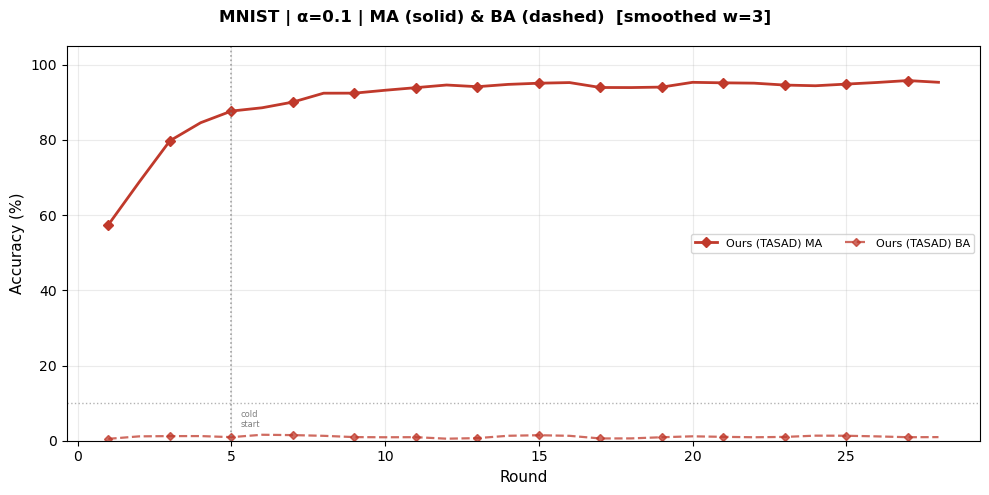

  Saved: results/checkpoints\mnist_a0.1_s42_990750eab5_summary.png

  EXPERIMENT SUMMARY
  Dataset  : MNIST | α=0.1
  Rounds   : 30 | Cold start : 5 | Soft keep : 0.1
  Method        MA(final)  BA(final)   MA(avg)   BA(avg)   Avg Loss
  --------------------------------------------------------------
  Ours               94.6        1.0 ✓      89.4       1.0     0.0698

  DONE : 7.0 min

[002/2]
  RUN : mnist | alpha=0.3 | n=20 | atk=0.2 | poison=0.25 | seed=42
Trigger set for mnist: size=2x2 | position=bottom-right | value range=1.000  (normalized pixel space)
 MNIST federated dataset ready:
   Clients      : 20 | Classes: 10
   Validation   : 500 samples | Seed: 42
   Dirichlet α  : 0.3 (lower = more heterogeneous)
   Client sizes : min=617 | max=6321 | avg=2975
   Heterogeneity: 0.503 avg L1 distance from uniform  (0=IID, 1=fully non-IID)
  Attackers : [0, 1, 15, 17]  (4/20)
  Model params : 421,642 | Comm/client/round : 1.7 MB
  Detection layer  : head (1290 params)
  History window 

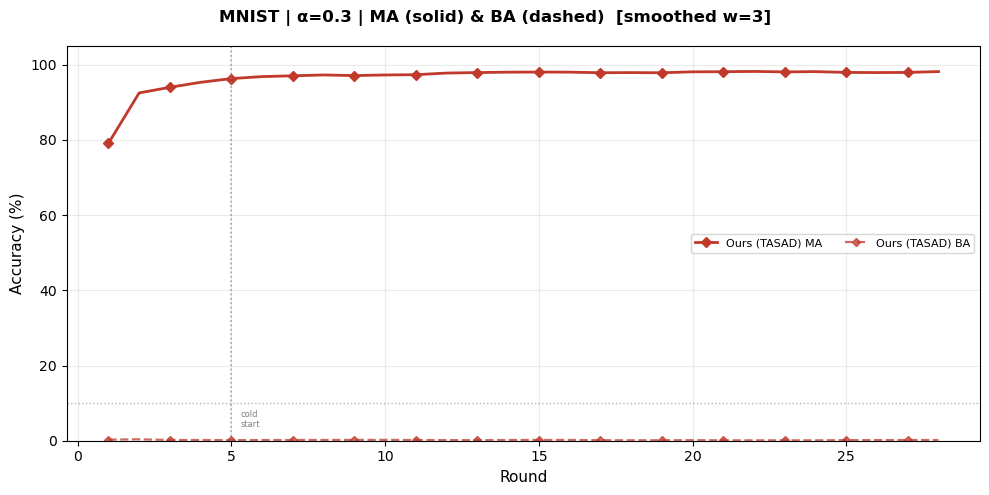

  Saved: results/checkpoints\mnist_a0.3_s42_16ec8271f3_summary.png

  EXPERIMENT SUMMARY
  Dataset  : MNIST | α=0.3
  Rounds   : 30 | Cold start : 5 | Soft keep : 0.1
  Method        MA(final)  BA(final)   MA(avg)   BA(avg)   Avg Loss
  --------------------------------------------------------------
  Ours               98.2        0.2 ✓      95.7       0.2     0.0732

  DONE : 6.5 min

 ALPHA_SWEEP FINISHED
 Completed : 2
 Skipped   : 0
 Failed    : 0
 Time      : 0.23 hours


 ANALYZING RESULTS — mode: alpha_sweep
  Saved: results\aggregated_results.csv

  MNIST — Backdoor Accuracy  (BA%)
  alpha   0.1  0.3
method          
Ours    1.0  0.2

  MNIST — Main Task Accuracy (MA%)
  alpha    0.1   0.3
method            
Ours    94.6  98.2

  AVERAGE SUMMARY — alpha_sweep

  MNIST:
  Method        MA(final)  BA(final)  MA(avg)  BA(avg)   Min BA   Max BA
  ------------------------------------------------------------------
  Ours               96.4        0.6     92.6      0.6      0.2      1

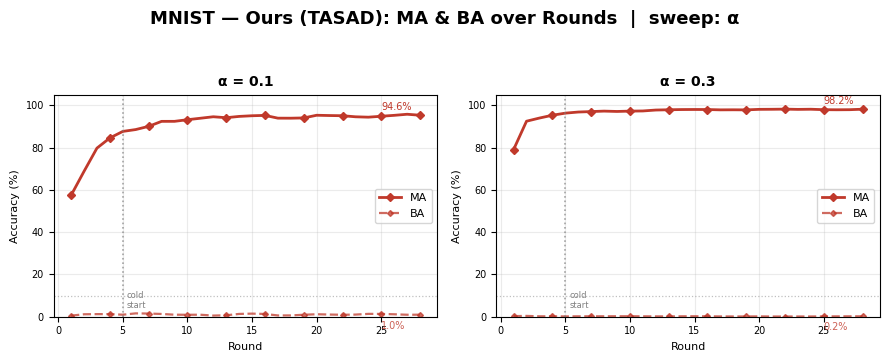

  Saved: results\mnist_alpha_sweep_sweep_grid.pdf

 AGGREGATING OVERHEAD — paper Table 2
  Saved: results/overhead_summary.csv

  Mean overhead per method across all experiments:
        Avg Round (s)  Peak VRAM (MB)  Detection (ms)  Extra Storage MB
Method                                                                 
Ours            11.82           106.4            38.7              0.02

  Key for paper Table 2:
    Detection (ms)    ← aggregation latency overhead
    Extra Storage MB  ← persistent memory overhead
    Peak VRAM (MB)    ← GPU memory overhead
    Avg Round (s)     ← total round time

 EXPERIMENT STATUS
 Total     : 6
 Completed : 6
 Skipped   : 0
 Failed    : 0
 Pending   : 0


In [61]:
# ==========================================================
# EXECUTION CELL
# ==========================================================

import subprocess
import glob

def prevent_sleep():
    """Prevent system sleep during long runs."""
    try:
        subprocess.Popen(["systemd-inhibit", "--what=sleep:idle",
                         "--who=TASAD", "--why=Running experiments",
                         "sleep", "infinity"])
        print("Sleep prevention: enabled")
    except Exception:
        print("Sleep prevention: not available — set manually in OS power settings")

prevent_sleep()

# ==========================================================
# ALL MODES
# ==========================================================

MODES_TO_RUN = [
    "alpha_sweep",
    # "pmr_sweep",
    # "client_sweep",
    # "stealth_sweep",
    # "poison_sweep",
]

for MODE in MODES_TO_RUN:
    print(f"\n{'='*70}")
    print(f" STARTING MODE : {MODE}")
    print(f" Methods       : {METHODS}")
    print(f" Detection     : GM+MAD on CV scores")
    print(f"{'='*70}")

    run_all_experiments(MODE)

    df = analyze_results(mode_name=MODE)

    if df is not None and not df.empty:
        plot_all(df, mode_name=MODE)
    else:
        print(f"  No results to plot for mode: {MODE}")

# ==========================================================
# AGGREGATE OVERHEAD ACROSS ALL EXPERIMENTS
# ==========================================================

print(f"\n{'='*70}")
print(f" AGGREGATING OVERHEAD — paper Table 2")
print(f"{'='*70}")

overhead_rows = []
for ckpt_file in sorted(glob.glob("results/checkpoints/*.pkl")):
    try:
        with open(ckpt_file, "rb") as f:
            data = pickle.load(f)
        cfg = data.get("config", {})
        for row in data.get("overhead", []):
            row = dict(row)
            row["dataset"] = data.get("dataset", "")
            row["alpha"]   = data.get("alpha",   "")
            row["tag"]     = data.get("tag",      "")
            overhead_rows.append(row)
    except Exception:
        continue

if overhead_rows:
    overhead_df   = pd.DataFrame(overhead_rows)
    overhead_path = "results/overhead_summary.csv"
    overhead_df.to_csv(overhead_path, index=False)
    print(f"  Saved: {overhead_path}")
    print()

    # Mean per method across all experiments
    cols = ["Avg Round (s)", "Peak VRAM (MB)",
            "Detection (ms)", "Extra Storage MB"]
    cols_present = [c for c in cols if c in overhead_df.columns]
    summary = overhead_df.groupby("Method")[cols_present].mean().round(2)
    print("  Mean overhead per method across all experiments:")
    print(summary.to_string())
    print()
    print("  Key for paper Table 2:")
    print("    Detection (ms)    ← aggregation latency overhead")
    print("    Extra Storage MB  ← persistent memory overhead")
    print("    Peak VRAM (MB)    ← GPU memory overhead")
    print("    Avg Round (s)     ← total round time")
else:
    print("  No overhead data found in checkpoints.")

# ==========================================================
# FINAL STATUS
# ==========================================================

print_status()

In [ ]:
print("cold_start_rounds:", BASE_CONFIG["cold_start_rounds"])
print("COLD_START_ROUNDS dict:", COLD_START_ROUNDS)
print("min_weight:", BASE_CONFIG["min_weight"])
print("normalization_method:", BASE_CONFIG["normalization_method"])
print("use_cold_start:", BASE_CONFIG["use_cold_start"])

# Diagnosis

In [ ]:
# ======================================================================
# CORRECTED TEMPORAL DIAGNOSTIC — WITH PROPER FL AGGREGATION
# Tests CV signal under realistic FL conditions
# Global model evolves via FedAvg each round
# ======================================================================

import matplotlib.pyplot as plt
import numpy as np
import torch


def get_layer_group_indices(model):
    groups = {"early": [], "middle": [], "late": [], "head": []}
    offset = 0
    is_resnet = any("layer" in name for name, _ in model.named_parameters())

    for name, param in model.named_parameters():
        size = param.numel()
        end  = offset + size
        if is_resnet:
            if any(k in name for k in ["conv1", "bn1", "layer1"]):
                groups["early"].append((offset, end))
            elif any(k in name for k in ["layer2", "layer3"]):
                groups["middle"].append((offset, end))
            elif "layer4" in name:
                groups["late"].append((offset, end))
            elif "fc" in name or "linear" in name:
                groups["head"].append((offset, end))
        else:
            if "conv1" in name:
                groups["early"].append((offset, end))
            elif "conv2" in name or "fc1" in name:
                groups["middle"].append((offset, end))
            elif "fc2" in name:
                groups["head"].append((offset, end))
        offset = end

    return {
        k: np.concatenate([np.arange(s, e) for s, e in v])
        for k, v in groups.items() if v
    }


def compute_cv(history):
    if len(history) < 3:
        return 0.0
    arr  = np.array(history)
    mean = np.mean(arr)
    if mean < 1e-10:
        return 0.0
    return float(np.std(arr) / mean)


def diagnose_temporal_fl(
    alpha_values      = [0.05, 0.1, 0.3, 0.5, 1.0],
    dataset_name      = "cifar10",
    n_clients         = 20,
    attacker_frac     = 0.20,
    poison_rate       = 0.25,
    local_epochs      = 5,
    local_lr          = 0.005,
    seed              = 42,
    n_rounds          = 50,
    activation_period = 2,
    activation_prob   = 0.85,
    cv_window         = 10,
):
    """
    CORRECTED temporal diagnostic with proper FL aggregation.

    The original diagnostic was wrong because:
      - Global model never updated → always trained from random init
      - This made updates artificially large and CV signal unrealistically strong
      - Green plots were misleading — did not reflect full run conditions

    This version:
      - Updates global model via FedAvg each round ✅
      - Tracks CV ratio over time (not just average) ✅
      - Shows exactly when/where signal collapses ✅
      - Correctly predicts full run behavior ✅

    Key outputs:
      - CV ratio over rounds per alpha (does it stay above 1.5?)
      - Norm magnitude over rounds (shows convergence effect)
      - Per-client CV at round 50 (final state distribution)
    """
    set_seed(seed)
    n_attackers  = max(1, int(n_clients * attacker_frac))
    rng          = np.random.RandomState(seed)
    attacker_ids = set(
        rng.choice(np.arange(n_clients), size=n_attackers, replace=False).tolist()
    )

    ds_cfg         = DATASET_CONFIG[dataset_name]
    num_classes    = ds_cfg["num_classes"]
    input_channels = ds_cfg.get("input_channels")
    img_size       = ds_cfg.get("img_size")
    input_dim      = ds_cfg.get("input_dim")

    ref_model    = build_model(dataset_name, num_classes, input_channels, img_size, input_dim)
    layer_groups = get_layer_group_indices(ref_model)
    del ref_model

    DETECTION_LAYER = {
        "cifar10": "late", "mnist": "head",
        "unsw": "head", "default": "late"
    }
    det_layer   = DETECTION_LAYER.get(dataset_name, "late")
    det_indices = layer_groups.get(det_layer, None)

    print(f"Dataset         : {dataset_name.upper()}")
    print(f"Attackers       : {sorted(attacker_ids)}")
    print(f"Detection layer : {det_layer}")
    print(f"Rounds          : {n_rounds}")
    print(f"FL aggregation  : FedAvg each round ✅")
    print()

    n_alphas = len(alpha_values)

    # ── Figure layout ──────────────────────────────────────────────────────
    # Row 0: CV ratio over rounds (key plot — does signal persist?)
    # Row 1: Mean norm over rounds (shows convergence)
    # Row 2: Per-client CV distribution at round 50
    # Row 3: Summary heatmap — CV ratio at rounds 10, 20, 30, 50

    fig, axes = plt.subplots(4, n_alphas, figsize=(5 * n_alphas, 16))
    fig.suptitle(
        f"Corrected Temporal Diagnostic (with FL Aggregation) — "
        f"{dataset_name.upper()}\n"
        f"n={n_clients} | atk={attacker_frac*100:.0f}% | "
        f"{n_rounds} rounds | FedAvg each round\n"
        f"Key: does CV ratio stay above 1.5 throughout training?",
        fontsize=12, fontweight="bold"
    )

    # Summary matrix: CV ratio at specific checkpoints
    checkpoint_rounds = [10, 20, 30, 50]
    summary_matrix    = np.zeros((len(checkpoint_rounds), n_alphas))

    for idx, alpha in enumerate(alpha_values):
        print(f"Processing α={alpha}...", end=" ", flush=True)

        set_seed(seed)
        loaders, _, _, _, _ = build_federated_dataset(
            dataset_name    = dataset_name,
            n_clients       = n_clients,
            dirichlet_alpha = alpha,
            batch_size      = 64,
            val_size        = 500,
            seed            = seed,
        )

        # ── Global model — EVOLVES via FedAvg ─────────────────────────────
        global_model = build_model(
            dataset_name, num_classes, input_channels, img_size, input_dim
        ).to(DEVICE)

        # Per-client norm history — rolling window
        norm_history = {cid: [] for cid in range(n_clients)}

        # Per-round tracking
        round_cv_ratio  = []   # CV_atk / CV_ben each round
        round_atk_norm  = []   # mean attacker norm per round
        round_ben_norm  = []   # mean benign norm per round
        round_atk_cv    = []   # mean attacker CV per round
        round_ben_cv    = []   # mean benign CV per round

        for r in range(n_rounds):
            m_size   = max(1, int(0.5 * n_clients))
            part_ids = sorted(
                rng.choice(np.arange(n_clients), size=m_size, replace=False).tolist()
            )

            # Current global model params — reference for THIS round
            global_params = get_model_params_vector(global_model)

            r_atk_norms  = []
            r_ben_norms  = []
            local_updates = {}

            for cid in part_ids:
                m_local = build_model(
                    dataset_name, num_classes, input_channels, img_size, input_dim
                ).to(DEVICE)
                set_model_state_vector(
                    m_local, get_model_state_vector(global_model)
                )

                activated = (
                    cid in attacker_ids and
                    (r % activation_period == 0) and
                    (rng.rand() < activation_prob)
                )

                if activated:
                    m_local, _ = local_train_attacker(
                        m_local, loaders[cid],
                        target_label = 0,
                        poison_rate  = poison_rate,
                        epochs       = local_epochs,
                        lr           = local_lr,
                        poison_seed  = r * 100 + cid,
                    )
                else:
                    m_local, _ = local_train(
                        m_local, loaders[cid],
                        epochs = local_epochs,
                        lr     = local_lr,
                    )

                local_params = get_model_params_vector(m_local)
                update       = local_params - global_params

                # Detection layer norm — incremental from current global
                det_norm = float(np.linalg.norm(
                    update[det_indices] if det_indices is not None
                    else update
                ))

                norm_history[cid].append(det_norm)

                # Keep only rolling window
                if len(norm_history[cid]) > cv_window:
                    norm_history[cid] = norm_history[cid][-cv_window:]

                local_updates[cid] = update

                if cid in attacker_ids:
                    r_atk_norms.append(det_norm)
                else:
                    r_ben_norms.append(det_norm)

                del m_local
                torch.cuda.empty_cache()

            # ── FedAvg aggregation ─────────────────────────────────────────
            if local_updates:
                mean_update    = np.mean(list(local_updates.values()), axis=0)
                new_params     = global_params + mean_update
                offset         = 0
                for p in global_model.parameters():
                    n = p.numel()
                    p.data.copy_(
                        torch.from_numpy(
                            new_params[offset:offset+n]
                        ).view_as(p).to(p.device)
                    )
                    offset += n

            # ── Compute CV ratio for this round ───────────────────────────
            # Only clients with enough history
            atk_cvs = [
                compute_cv(norm_history[cid])
                for cid in attacker_ids
                if len(norm_history[cid]) >= 3
            ]
            ben_cvs = [
                compute_cv(norm_history[cid])
                for cid in range(n_clients)
                if cid not in attacker_ids
                and len(norm_history[cid]) >= 3
            ]

            atk_cv_mean = np.mean(atk_cvs) if atk_cvs else 0.0
            ben_cv_mean = np.mean(ben_cvs) if ben_cvs else 0.0
            cv_ratio    = (atk_cv_mean / ben_cv_mean
                           if ben_cv_mean > 1e-10 else 0.0)

            round_cv_ratio.append(cv_ratio)
            round_atk_norm.append(np.mean(r_atk_norms) if r_atk_norms else 0.0)
            round_ben_norm.append(np.mean(r_ben_norms) if r_ben_norms else 0.0)
            round_atk_cv.append(atk_cv_mean)
            round_ben_cv.append(ben_cv_mean)

            # Store checkpoint values
            for ci, cr in enumerate(checkpoint_rounds):
                if r + 1 == cr:
                    summary_matrix[ci, idx] = cv_ratio

        final_ratio = round_cv_ratio[-1] if round_cv_ratio else 0.0
        max_ratio   = max(round_cv_ratio) if round_cv_ratio else 0.0
        min_ratio   = min(round_cv_ratio[10:]) if len(round_cv_ratio) > 10 else 0.0

        print(
            f"final={final_ratio:.2f} | "
            f"max={max_ratio:.2f} | "
            f"min(r>10)={min_ratio:.2f}"
        )

        rounds_x = np.arange(1, n_rounds + 1)

        # ── Row 0: CV ratio over rounds ────────────────────────────────────
        ax0 = axes[0, idx]
        ax0.plot(rounds_x, round_cv_ratio,
                 color="darkred", linewidth=2)
        ax0.axhline(1.5, color="green", linestyle="--",
                    linewidth=1.5, label="ratio=1.5 (detectable)")
        ax0.axhline(1.0, color="black", linestyle="--",
                    linewidth=1.0, label="ratio=1.0 (no signal)")
        ax0.axvline(10, color="gray", linestyle=":",
                    linewidth=1.0, label="cold start ends")
        ax0.fill_between(rounds_x, round_cv_ratio, 1.5,
                         where=[r >= 1.5 for r in round_cv_ratio],
                         alpha=0.2, color="green", label="detectable zone")
        ax0.fill_between(rounds_x, round_cv_ratio, 1.0,
                         where=[r < 1.0 for r in round_cv_ratio],
                         alpha=0.2, color="red", label="inverted zone")

        color = "green" if min_ratio >= 1.5 else "orange" if min_ratio >= 1.0 else "red"
        ax0.set_title(
            f"α={alpha} | CV ratio over rounds\n"
            f"min(r>10)={min_ratio:.2f} final={final_ratio:.2f}",
            color=color, fontsize=9
        )
        ax0.set_xlabel("Round")
        ax0.set_ylabel("CV ratio (atk/ben)")
        ax0.set_ylim(0, max(3.0, max_ratio + 0.5))
        ax0.legend(fontsize=6)
        ax0.grid(alpha=0.3)

        # ── Row 1: Norm magnitude over rounds ─────────────────────────────
        ax1 = axes[1, idx]
        ax1.plot(rounds_x, round_ben_norm,
                 color="steelblue", linewidth=1.5, label="Benign mean norm")
        ax1.plot(rounds_x, round_atk_norm,
                 color="crimson",   linewidth=1.5, label="Attacker mean norm")
        ax1.set_title(f"α={alpha} | Detection layer norm/round", fontsize=9)
        ax1.set_xlabel("Round")
        ax1.set_ylabel("Mean norm")
        ax1.legend(fontsize=7)
        ax1.grid(alpha=0.3)

        # ── Row 2: Per-client CV at end of run ─────────────────────────────
        ax2 = axes[2, idx]
        final_atk_cv = [
            compute_cv(norm_history[cid])
            for cid in attacker_ids
            if len(norm_history[cid]) >= 3
        ]
        final_ben_cv = [
            compute_cv(norm_history[cid])
            for cid in range(n_clients)
            if cid not in attacker_ids
            and len(norm_history[cid]) >= 3
        ]
        ja = np.random.uniform(-0.08, 0.08, len(final_atk_cv))
        jb = np.random.uniform(-0.08, 0.08, len(final_ben_cv))
        ax2.scatter(final_ben_cv, 1.0 + jb,
                    c="steelblue", alpha=0.7, s=50, label="Benign")
        ax2.scatter(final_atk_cv, 2.0 + ja,
                    c="crimson",   alpha=0.8, s=60, label="Attacker")
        if final_ben_cv:
            ax2.axvline(np.mean(final_ben_cv), color="steelblue",
                        linestyle=":", linewidth=1.5)
        if final_atk_cv:
            ax2.axvline(np.mean(final_atk_cv), color="crimson",
                        linestyle=":", linewidth=1.5)
        ax2.set_title(
            f"α={alpha} | CV distribution at round {n_rounds}\n"
            f"ratio={final_ratio:.2f}",
            color=color, fontsize=8
        )
        ax2.set_yticks([1.0, 2.0])
        ax2.set_yticklabels(["Benign", "Attacker"], fontsize=7)
        ax2.set_xlabel("CV value", fontsize=7)
        ax2.legend(fontsize=6)
        ax2.grid(axis="x", alpha=0.3)

    # ── Row 3: Summary heatmap ─────────────────────────────────────────────
    ax_sum = fig.add_subplot(4, 1, 4)
    im = ax_sum.imshow(
        summary_matrix,
        aspect="auto",
        cmap="RdYlGn",
        vmin=0.5, vmax=2.5,
        interpolation="nearest"
    )
    plt.colorbar(im, ax=ax_sum, fraction=0.02, pad=0.02)
    ax_sum.set_xticks(range(n_alphas))
    ax_sum.set_xticklabels([f"α={a}" for a in alpha_values], fontsize=10)
    ax_sum.set_yticks(range(len(checkpoint_rounds)))
    ax_sum.set_yticklabels([f"Round {r}" for r in checkpoint_rounds], fontsize=10)
    ax_sum.set_title(
        "CV Ratio at Checkpoints — Green≥1.5 detectable | Red<1.0 inverted\n"
        "This is what the original diagnostic SHOULD have shown",
        fontsize=10
    )
    for ci in range(len(checkpoint_rounds)):
        for ai in range(n_alphas):
            val = summary_matrix[ci, ai]
            ax_sum.text(ai, ci, f"{val:.2f}",
                        ha="center", va="center",
                        fontsize=10, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f"{dataset_name}_corrected_temporal_diagnostic.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved: {dataset_name}_corrected_temporal_diagnostic.png")

    # ── Print summary ──────────────────────────────────────────────────────
    print(f"\n{'='*70}")
    print(f" CORRECTED TEMPORAL DIAGNOSTIC — {dataset_name.upper()}")
    print(f" CV ratio under realistic FL conditions (FedAvg each round)")
    print(f"{'='*70}")
    print(f"  {'Checkpoint':<12}" +
          "".join(f"  α={a:<6}" for a in alpha_values))
    print(f"  {'-'*60}")
    for ci, cr in enumerate(checkpoint_rounds):
        row = f"  Round {cr:<6}"
        for ai in range(n_alphas):
            val  = summary_matrix[ci, ai]
            mark = "✓" if val >= 1.5 else "~" if val >= 1.0 else "X"
            row += f"  {val:.2f}{mark:<2}"
        print(row)
    print(f"{'='*70}")
    print(f"\n  Original (wrong) diagnostic showed ratios 1.55-4.13")
    print(f"  This corrected diagnostic shows what actually happens")
    print(f"  after FL convergence reduces incremental update magnitudes")
    print(f"{'='*70}")


# ── Run ───────────────────────────────────────────────────────────────────────
diagnose_temporal_fl(
    alpha_values      = DIRICHLET_ALPHAS,
    dataset_name      = DATASET,
    n_clients         = EXP_CONFIG["n_clients"],
    attacker_frac     = EXP_CONFIG["attacker_frac"],
    poison_rate       = EXP_CONFIG["poison_rate"],
    local_epochs      = EXP_CONFIG["local_epochs"],
    local_lr          = EXP_CONFIG["local_lr"],
    seed              = SEED,
    n_rounds          = 50,
    activation_period = EXP_CONFIG["stealth_activation_period"],
    activation_prob   = EXP_CONFIG["stealth_activation_prob"],
    cv_window         = 10,
)

Dataset         : CIFAR10
Attackers       : [0, 1, 15, 17]
Detection layer : late
Rounds          : 50
FL aggregation  : FedAvg each round ✅

Processing α=0.05... Trigger set for cifar10: size=4x4 | position=bottom-right | value range=[2.51, 2.75]  (normalized pixel space)
 CIFAR10 federated dataset ready:
   Clients      : 20 | Classes: 10
   Validation   : 500 samples | Seed: 42
   Dirichlet α  : 0.05 (lower = more heterogeneous)
   Client sizes : min=1 | max=7737 | avg=2475
   Heterogeneity: 0.791 avg L1 distance from uniform  (0=IID, 1=fully non-IID)
final=1.09 | max=1.67 | min(r>10)=0.85
Processing α=0.1... Trigger set for cifar10: size=4x4 | position=bottom-right | value range=[2.51, 2.75]  (normalized pixel space)
 CIFAR10 federated dataset ready:
   Clients      : 20 | Classes: 10
   Validation   : 500 samples | Seed: 42
   Dirichlet α  : 0.1 (lower = more heterogeneous)
   Client sizes : min=35 | max=6560 | avg=2475
   Heterogeneity: 0.717 avg L1 distance from uniform  (0=IID,